# Homework 1
### Anil Egin 2241724
### Joey Shauhin Biebuyck 2285440

In [ ]:
# if you have got import errors for the required packages, you can do so by running the following command:
#!pip install --no-cache-dir transformers==4.38.2 tokenizers==0.15.2 huggingface_hub sentence-transformers datasets accelerate

INFO: pip is looking at multiple versions of sentence-transformers to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of sentence-transformers to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 162.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 314.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 456.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [sentence-transformers]ence-transformers]


## Analyzing the data
We first import the neccessary libraries and load the dataset

In [1]:
import os
import json
import math
import pandas as pd

import torch
import torch.nn.functional as F
import numpy as np
import transformers

from enum import Enum
import copy
from dataclasses import dataclass
from datasets import Dataset, DatasetDict, load_dataset, load_from_disk
from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification
from sentence_transformers import SentenceTransformer, models 
from tqdm.auto import tqdm

from pathlib import Path

for folder in ("plots", "results", "models"):
    Path(folder).mkdir(exist_ok=True)

print("PyTorch Version:", torch.__version__)
print("Transformers Version:", transformers.__version__)
print("CUDA Available:", torch.cuda.is_available())

import gc
import torch

def free_gpu_memory():
    if not torch.cuda.is_available():
        return
        
    reserved_before = torch.cuda.memory_reserved()
    
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
    
    freed = (reserved_before - torch.cuda.memory_reserved()) / (1024 ** 2)
    free_now = torch.cuda.mem_get_info()[0] / (1024 ** 2)
    
    print(f"GPU memory cleared. Released: {freed:.1f} MB, Available now: {free_now:.1f} MB")

PyTorch Version: 2.11.0+cu130
Transformers Version: 4.38.2
CUDA Available: True


In [ ]:
#reproducibility step
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
token = 'HF DATASET TOKEN'

In [ ]:
ds = load_dataset("sapienzanlp-course-materials/hw-mnlp-2026", token=token)
print(type(ds))

<class 'datasets.dataset_dict.DatasetDict'>


In [4]:
# sanity check for duplicates in the training queries
queries = ds["train"]["query"]
total_count = len(queries)
unique_count = len(set(queries))

if total_count == unique_count:
    print(f"All {total_count} queries are unique")
else:
    print(f"Found {total_count - unique_count} duplicates")
    print(f"Total: {total_count} | Unique: {unique_count}")

All 8000 queries are unique


Automatically select the optimal device

In [4]:
device = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using device: {device}")

Using device: cuda


Then we inspect the data

In [6]:
ds["train"].shape[0]

8000

In [7]:
print('Query:', ds['train'][20]['query'], '\nAnswer:', ds['train'][20]['answer_pos']+1)
print("---"*100)

print('Chunks: ', "\n".join(ds['train'][20]['candidate_chunks']))

Query: who sung the phineas and ferb theme song 
Answer: 3
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Chunks:  Phineas and Ferb is the first soundtrack album for the Disney Channel television series, Phineas and Ferb, which was released September 22, 2009 in the United States on compact disc by Walt Disney Records and Hollywood Records. The album contains 26 songs from season one. It also contains the bonus track "The F-Games" that can only be heard online.
As of March 6, 2010, the soundtrack had sold about 122,600 copies in the United States.
The artists on the soundtrack all are in Phineas and Ferb except for Bowling for Soup who performs the theme tune for the series. The song "Gitchee Gitchee Goo" performed by Vincent Martella &

## Logic for specific experiments
First we define the hit@k evaluation metric

In [5]:
def hit_at_k(correct_index, ranking, k=5):
    top_k = ranking[:k]
    return 1 if correct_index in top_k else 0

def mean_hit_at_k(results, k=5):
    hit_at_k_scores = 0
    for res in results:
        hit_at_k_scores += hit_at_k(correct_index=res["correct_index"], ranking=res["ranking"], k=k)
    return hit_at_k_scores / len(results)

Next we define the Mean Reciprocal Rank (MRR) performance metric

In [6]:
#def reciprocal_rank(correct_index, ranking):
#  return 1 / ranking.index(correct_index)

def reciprocal_rank(correct_index, ranking):
    try:
        # lists start at 1
        rank = ranking.index(correct_index) + 1
        return 1.0 / rank
    except ValueError:
        # If the correct index is not in the ranking at all, the score is 0
        return 0.0

def mean_reciprocal_rank(results):
  MRR_score = 0
  for res in results:
    MRR_score += reciprocal_rank(correct_index=res["correct_index"], ranking=res["ranking"])
  return MRR_score / len(results)

Next we define a class that allows us to easily replace parameters in our experiments

In [7]:
distance_metrics = ["cosine", "euclidean", "angular"]

class RetrievalEngine:
    def __init__(self, model, device):
        self.model = model
        self.device = device
        self.model.eval() 
        
        # caching will allow us to compute other metrics in way less time 
        self.embedding_cache = {}
        self.cached_dataset_id = None

    def get_embeddings(self, texts, instruct=False):
        with torch.no_grad():
            if not instruct: #bge needs instruct
                embeddings = self.model.encode(
                    texts, 
                    convert_to_tensor=True, 
                    device=self.device, 
                    show_progress_bar=False
                )
            else: 
                # we got that from bge documentation
                instruction = "Represent this sentence for searching relevant passages: "
                
                prompted_texts = [instruction + t for t in texts]
                
                embeddings = self.model.encode(
                    prompted_texts, 
                    convert_to_tensor=True, 
                    device=self.device, 
                    show_progress_bar=False,
                )
        return embeddings # not normalized, raw embeddings

    def get_ranking(self, query_emb, chunk_embs, distance_metric="cosine"):
        if distance_metric == "cosine":
            #normalization
            query_norm = F.normalize(query_emb, p=2, dim=1)
            chunk_norm = F.normalize(chunk_embs, p=2, dim=1)
            #only dot product since vectors are normalized
            scores = torch.mm(chunk_norm, query_norm.T).squeeze(1)
            is_largest_best = True  # Higher score = more similar

        elif distance_metric == "euclidean":
            # L2 Distance
            # torch.cdist computes distances between all pairs of rows
            scores = torch.cdist(chunk_embs, query_emb, p=2).squeeze(1)
            is_largest_best = False # Lower score = closer distance

        elif distance_metric == "angular":
            query_norm = F.normalize(query_emb, p=2, dim=1)
            chunk_norm = F.normalize(chunk_embs, p=2, dim=1)
            # Angular Distance = arccos(cosine_similarity) / pi
            cos_sim = torch.mm(chunk_norm, query_norm.T).squeeze(1)
            cos_sim = torch.clamp(cos_sim, -1.0 + 1e-7, 1.0 - 1e-7)
            scores = torch.arccos(cos_sim) / torch.pi
            is_largest_best = False # Lower angle = closer distance
            
        else:
            raise ValueError(f"Unknown metric")

        # chunks are sorted from highest score to lowest
        _, full_ranking = torch.topk(scores, scores.shape[0], largest=is_largest_best)
        
        return full_ranking.tolist()

    def evaluate_dataset(self, 
                        dataset, k=[1, 3, 5],
                        distance_metric="cosine", 
                        eval_metric="all", 
                        use_cache=True, 
                        instruct = False,
                        return_predictions=False
                        ):
        
        all_results = []
        
        # caching if we are evaluating a completely new dataset, it wipes the old cache
        if use_cache and id(dataset) != self.cached_dataset_id:
            self.embedding_cache.clear()
            self.cached_dataset_id = id(dataset)
        elif not use_cache:
            self.embedding_cache.clear()

        for i, row in enumerate(tqdm(dataset, desc=f"Evaluating Retrieval")):
            query_id = row["query_id"]
            correct_index = row.get("answer_pos", -1)

            # checking if embeddings are already in our cache
            if use_cache and i in self.embedding_cache:
                query_emb, chunk_embs = self.embedding_cache[i]
            else:
                # from scratch
                query = row["query"]
                candidate_chunks = row["candidate_chunks"]

                query_emb = self.get_embeddings([query], instruct=instruct) # [1, embedding space]
                chunk_embs = self.get_embeddings(candidate_chunks) # [N, embedding space]
                
                # Save to cache for the next time we run evaluate_dataset
                if use_cache:
                    self.embedding_cache[i] = (query_emb, chunk_embs)

            full_ranking = self.get_ranking(query_emb, chunk_embs, distance_metric)

            all_results.append({
                "query_id": query_id, 
                "correct_index": correct_index,
                "ranking": full_ranking
            })

        print("\n" + "---"*30)
        print("FINAL EVALUATION RESULTS")
        print(f"Distance metric: {distance_metric}")
        print("---"*30)

        final_results = {}
        
        # hit@k logic we will call our functions
        if eval_metric in ["hitk", "all"]:
            if isinstance(k, list):
                for k_val in k:
                    score = mean_hit_at_k(all_results, k=k_val)
                    final_results[f"Hit@{k_val}"] = score
                    print(f"Mean Hit@{k_val:<2}: {score:.4f}")
            else:
                score = mean_hit_at_k(all_results, k=k)
                final_results[f"Hit@{k}"] = score
                print(f"Mean Hit@{k:<2}: {score:.4f}")
                
        # MRR logic 
        if eval_metric in ["mrr", "all"]:
            score = mean_reciprocal_rank(all_results)
            final_results["MRR"] = score
            print(f"Mean MRR  : {score:.4f}")

        print("-" * 30)

        if return_predictions:
            return final_results, all_results

        if eval_metric == "all":
            return final_results 
            
        elif eval_metric == "mrr":
            return final_results["MRR"] 
            
        elif eval_metric == "hitk":
            if isinstance(k, list):
                return final_results 
            else:
                return final_results[f"Hit@{k}"]

    def clear_cache(self):
        """MUST be called after model weights change."""
        self.embedding_cache.clear()
        self.cached_dataset_id = None
        print("cache successfully cleared!")

json output function

In [8]:
import json

def export_predictions_to_jsonl(raw_results, variant, mode):

    output_filename = f"results/TheLastLanguageBenders-{mode}-{variant}.jsonl"

    with open(output_filename, 'w', encoding='utf-8') as f:
        for res in raw_results:
            query_id_str = str(res["query_id"])
            full_ranking_list = res["ranking"]
            
            # exact format: {"query_id": [0, 3, 1, ...]}
            json_line = {query_id_str: full_ranking_list}
            
            f.write(json.dumps(json_line) + "\n")

            
    print(f"Successfully saved {len(raw_results)} predictions to {output_filename}!")

## Load Models
Here we load Distilbert-base-uncased, all-MiniLM-L6-v2, ..., and ...

In [62]:
distilbert = "distilbert-base-uncased"
all_mini = "all-MiniLM-L6-v2"

Now we can run it on our data

## Baseline tests
### DistilBERT-base-uncased

below we achieved baseline scores for the distilbert and all-minilm

In [63]:
word_embedding_model = models.Transformer(distilbert)

# this already provides us mean pooling in the exact format how distilbert needs it
pooling_model = models.Pooling(
    word_embedding_model.get_word_embedding_dimension(),
    pooling_mode_mean_tokens=True
)

model = SentenceTransformer(modules=[word_embedding_model, pooling_model])
model = model.to(device)

# to compute metrics
engine = RetrievalEngine(model=model, device=device)

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [64]:
print("Evaluating Base DistilBERT on Test Set...")
for metric in distance_metrics:
    test_results = engine.evaluate_dataset(ds["test"], k=[1, 3, 5], distance_metric=metric, eval_metric="all")

Evaluating Base DistilBERT on Test Set...


Evaluating Retrieval:   0%|          | 0/2000 [00:00<?, ?it/s]


------------------------------------------------------------------------------------------
FINAL EVALUATION RESULTS
Distance metric: cosine
------------------------------------------------------------------------------------------
Mean Hit@1 : 0.1765
Mean Hit@3 : 0.4435
Mean Hit@5 : 0.6045
Mean MRR  : 0.3657
------------------------------


Evaluating Retrieval:   0%|          | 0/2000 [00:00<?, ?it/s]


------------------------------------------------------------------------------------------
FINAL EVALUATION RESULTS
Distance metric: euclidean
------------------------------------------------------------------------------------------
Mean Hit@1 : 0.1650
Mean Hit@3 : 0.4150
Mean Hit@5 : 0.5810
Mean MRR  : 0.3488
------------------------------


Evaluating Retrieval:   0%|          | 0/2000 [00:00<?, ?it/s]


------------------------------------------------------------------------------------------
FINAL EVALUATION RESULTS
Distance metric: angular
------------------------------------------------------------------------------------------
Mean Hit@1 : 0.1765
Mean Hit@3 : 0.4435
Mean Hit@5 : 0.6045
Mean MRR  : 0.3657
------------------------------


### all-MiniLM-L6-v2

In [65]:
model = SentenceTransformer('all-MiniLM-L6-v2').to(device)

engine = RetrievalEngine(model=model, device=device)

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [66]:
print("Evaluating Base all-MiniLM on Test Set...")
for metric in distance_metrics:
    test_results = engine.evaluate_dataset(ds["test"], k=[1, 3, 5], distance_metric=metric, eval_metric="all")

Evaluating Base all-MiniLM on Test Set...


Evaluating Retrieval:   0%|          | 0/2000 [00:00<?, ?it/s]


------------------------------------------------------------------------------------------
FINAL EVALUATION RESULTS
Distance metric: cosine
------------------------------------------------------------------------------------------
Mean Hit@1 : 0.4480
Mean Hit@3 : 0.7165
Mean Hit@5 : 0.8080
Mean MRR  : 0.6093
------------------------------


Evaluating Retrieval:   0%|          | 0/2000 [00:00<?, ?it/s]


------------------------------------------------------------------------------------------
FINAL EVALUATION RESULTS
Distance metric: euclidean
------------------------------------------------------------------------------------------
Mean Hit@1 : 0.4480
Mean Hit@3 : 0.7165
Mean Hit@5 : 0.8080
Mean MRR  : 0.6093
------------------------------


Evaluating Retrieval:   0%|          | 0/2000 [00:00<?, ?it/s]


------------------------------------------------------------------------------------------
FINAL EVALUATION RESULTS
Distance metric: angular
------------------------------------------------------------------------------------------
Mean Hit@1 : 0.4480
Mean Hit@3 : 0.7165
Mean Hit@5 : 0.8080
Mean MRR  : 0.6093
------------------------------


### BGE-Base

In [43]:
model = SentenceTransformer('BAAI/bge-base-en-v1.5').to(device)

engine = RetrievalEngine(model=model, device=device)

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In the hugging face website it is advised that query should be encoded with a helper prompt in the beginning which is:
"Represent this sentence for searching relevant passages: ". we will check performances of both ways

In [17]:
#with helper instruct

print("Evaluating Base BGE-base on Test Set...")
for metric in distance_metrics:
    test_results = engine.evaluate_dataset(ds["test"], k=[1, 3, 5], distance_metric=metric, eval_metric="all", instruct=True)

Evaluating Base BGE-base on Test Set...


Evaluating Retrieval:   0%|          | 0/2000 [00:00<?, ?it/s]


------------------------------------------------------------------------------------------
FINAL EVALUATION RESULTS
Distance metric: cosine
------------------------------------------------------------------------------------------
Mean Hit@1 : 0.5460
Mean Hit@3 : 0.8040
Mean Hit@5 : 0.8815
Mean MRR  : 0.6922
------------------------------


Evaluating Retrieval:   0%|          | 0/2000 [00:00<?, ?it/s]


------------------------------------------------------------------------------------------
FINAL EVALUATION RESULTS
Distance metric: euclidean
------------------------------------------------------------------------------------------
Mean Hit@1 : 0.5460
Mean Hit@3 : 0.8040
Mean Hit@5 : 0.8815
Mean MRR  : 0.6922
------------------------------


Evaluating Retrieval:   0%|          | 0/2000 [00:00<?, ?it/s]


------------------------------------------------------------------------------------------
FINAL EVALUATION RESULTS
Distance metric: angular
------------------------------------------------------------------------------------------
Mean Hit@1 : 0.5460
Mean Hit@3 : 0.8040
Mean Hit@5 : 0.8815
Mean MRR  : 0.6922
------------------------------


In [44]:
# without helper instruct

print("Evaluating Base BGE-base on Test Set...")
for metric in distance_metrics:
    test_results = engine.evaluate_dataset(ds["test"], k=[1, 3, 5], distance_metric=metric, eval_metric="all")

Evaluating Base BGE-base on Test Set...


Evaluating Retrieval:   0%|          | 0/2000 [00:00<?, ?it/s]


------------------------------------------------------------------------------------------
FINAL EVALUATION RESULTS
Distance metric: cosine
------------------------------------------------------------------------------------------
Mean Hit@1 : 0.5105
Mean Hit@3 : 0.7960
Mean Hit@5 : 0.8770
Mean MRR  : 0.6708
------------------------------


Evaluating Retrieval:   0%|          | 0/2000 [00:00<?, ?it/s]


------------------------------------------------------------------------------------------
FINAL EVALUATION RESULTS
Distance metric: euclidean
------------------------------------------------------------------------------------------
Mean Hit@1 : 0.5105
Mean Hit@3 : 0.7960
Mean Hit@5 : 0.8770
Mean MRR  : 0.6708
------------------------------


Evaluating Retrieval:   0%|          | 0/2000 [00:00<?, ?it/s]


------------------------------------------------------------------------------------------
FINAL EVALUATION RESULTS
Distance metric: angular
------------------------------------------------------------------------------------------
Mean Hit@1 : 0.5105
Mean Hit@3 : 0.7960
Mean Hit@5 : 0.8770
Mean MRR  : 0.6708
------------------------------


In [18]:
# deleting old variables if they exist
del model
del engine
#if 'model' in locals(): del model

free_gpu_memory()

GPU memory cleared. Released: 9574.0 MB | Available now: 21777.1 MB


## Fine-tuning
### DistilBert-base-uncased

#### 1st Approach: 
We will finetune DistilBert with sentence pairs. Instead of vanilla binary cross entropy, we will utilize "MultipleNegativesRankingLoss" in which it creates matrix of similarity with ground truth in contrast to other chunks from query-answer pairs.

To avoid overfitting we utilize early stopping where we keep the patience=2. If val loss does not improve 2 times in a row, we will stop the training and retrieve best state as checkpoint.

In [9]:
from torch.optim import AdamW
from sentence_transformers import losses

train_losses = []
val_losses = []

# Early Stopping parameters
patience = 2 
patience_counter = 0
best_val_loss = float('inf')
best_model_weights = None

num_epochs = 20 # we have early stopping so that it can stop before overfitting

word_embedding_model = models.Transformer('distilbert-base-uncased')

pooling_model = models.Pooling(
    word_embedding_model.get_word_embedding_dimension(),
    pooling_mode_mean_tokens=True
)

model = SentenceTransformer(modules=[word_embedding_model, pooling_model])
model = model.to(device)

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Sanity checks to see how model works

In [9]:
# dummy text
sentences = [
    "Rome was founded in 753 BC.",
    "The city of Rome was established in the 8th century BC."
]
embeddings = model.encode(sentences, convert_to_tensor=True)

print("Output Type:", type(embeddings))
print("Output Shape:", embeddings.shape)
print("Preview of first 5 dimensions:", embeddings[0][:5])

sim = F.cosine_similarity(embeddings[0].unsqueeze(0), embeddings[1].unsqueeze(0))

print(f"Sentence 1: {sentences[0]}")
print(f"Sentence 2: {sentences[1]}")
print(f"Cosine Similarity: {sim.item():.4f}")

if embeddings.shape == (2, 768):
    print("Model produced correct embedding dimensions (768).")

Output Type: <class 'torch.Tensor'>
Output Shape: torch.Size([2, 768])
Preview of first 5 dimensions: tensor([ 0.1549, -0.2650, -0.2827, -0.0048, -0.3033])
Sentence 1: Rome was founded in 753 BC.
Sentence 2: The city of Rome was established in the 8th century BC.
Cosine Similarity: 0.9521
Model produced correct embedding dimensions (768).


In [10]:
from torch.utils.data import DataLoader
from sentence_transformers import InputExample
import matplotlib.pyplot as plt
from tqdm.auto import tqdm, trange


# we split 7000-1000 for train-dev split and convert hg data to input examples
split_dataset = ds["train"].train_test_split(test_size=1000, seed=42)
train_split = split_dataset["train"] 
val_split = split_dataset["test"]    

print(f"Training samples: {len(train_split)}")
print(f"Validation samples: {len(val_split)}")

def create_input_examples(dataset_split):
    examples = []
    for i in range(len(dataset_split)):
        query_text = dataset_split[i]["query"]
        correct_idx = dataset_split[i]["answer_pos"]
        correct_chunk = dataset_split[i]["candidate_chunks"][correct_idx]
        examples.append(InputExample(texts=[query_text, correct_chunk]))
    return examples

train_examples = create_input_examples(train_split)
val_examples = create_input_examples(val_split)

# dataloaders for batch training
train_dataloader = DataLoader(train_examples,
                            shuffle=True,
                            batch_size=32,
                            collate_fn=model.smart_batching_collate
                            )

val_dataloader = DataLoader(val_examples,
                            shuffle=False,
                            batch_size=32,
                            collate_fn=model.smart_batching_collate
                            )

Training samples: 7000
Validation samples: 1000


In [ ]:
# sentence pairs loss function
train_loss = losses.MultipleNegativesRankingLoss(model=model)

# Standard learning rate for fine-tuning transformers adam with weight decay
optimizer = AdamW(model.parameters(), lr=2e-5)

for epoch in trange(num_epochs, desc="Epochs"):
    model.train()
    total_train_loss = 0
    
    # training batches
    train_bar = tqdm(train_dataloader, desc=f"Train Batch (Ep {epoch+1})", leave=False)
    for batch in train_bar:
        optimizer.zero_grad()
        
        features, labels = batch
        for i in range(len(features)):
          for key in features[i]:
              if torch.is_tensor(features[i][key]):
                  features[i][key] = features[i][key].to(device)

        if torch.is_tensor(labels):
            labels = labels.to(device)
          
        loss_value = train_loss(features, labels)
        loss_value.backward()
        optimizer.step()
        
        total_train_loss += loss_value.item()
        train_bar.set_postfix({'loss': f"{loss_value.item():.4f}"})
        
    avg_train_loss = total_train_loss / len(train_dataloader)
    train_losses.append(avg_train_loss)
    
    # validation
    model.eval()
    total_val_loss = 0
    
    with torch.no_grad(): # No gradients for validation
        val_bar = tqdm(val_dataloader, desc=f"Val Batch (Ep {epoch+1})", leave=False)
        for batch in val_bar:
            features, labels = batch
            for i in range(len(features)):
              for key in features[i]:
                  if torch.is_tensor(features[i][key]):
                      features[i][key] = features[i][key].to(device)

            if torch.is_tensor(labels):
                labels = labels.to(device)
                
            # validation loss
            val_batch_loss = train_loss(features, labels)
            total_val_loss += val_batch_loss.item()
            val_bar.set_postfix({'val_loss': f"{val_batch_loss.item():.4f}"})
            
    avg_val_loss = total_val_loss / len(val_dataloader)
    val_losses.append(avg_val_loss)
    
    print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    
    # early stopping if val loss does not improve for patience times it stops and saves the best
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        # Save a deepcopy of the best model weights in memory
        best_model_weights = copy.deepcopy(model.state_dict())
        print("Best model updated!")
    else:
        patience_counter += 1
        print(f"No improvement. Patience: {patience_counter}/{patience}")
        
        if patience_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}!")
            break


Epochs:   0%|          | 0/20 [00:00<?, ?it/s]

Train Batch (Ep 1):   0%|          | 0/219 [00:00<?, ?it/s]

Val Batch (Ep 1):   0%|          | 0/32 [00:00<?, ?it/s]


Epoch 1 | Train Loss: 0.2364 | Val Loss: 0.1472
Best model updated!


Train Batch (Ep 2):   0%|          | 0/219 [00:00<?, ?it/s]

...

Val Batch (Ep 5):   0%|          | 0/32 [00:00<?, ?it/s]


Epoch 5 | Train Loss: 0.0176 | Val Loss: 0.1325
No improvement. Patience: 1/2


Train Batch (Ep 6):   0%|          | 0/219 [00:00<?, ?it/s]

Val Batch (Ep 6):   0%|          | 0/32 [00:00<?, ?it/s]


Epoch 6 | Train Loss: 0.0144 | Val Loss: 0.1291
No improvement. Patience: 2/2

Early stopping triggered at epoch 6!


In [ ]:
print("Loading best model weights...")
model.load_state_dict(best_model_weights)

model.save("models/distilbert-finetuned-best-infonce_sp")


Loading best model weights...


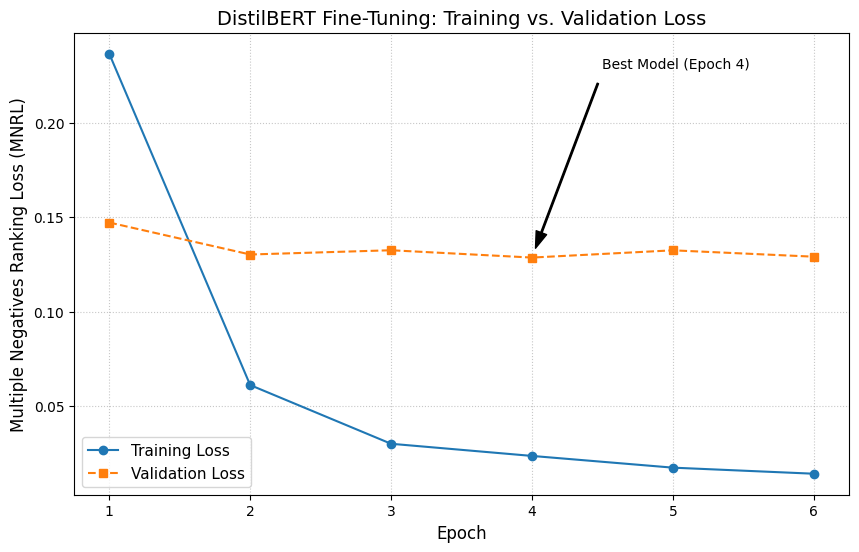

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

epochs_range = range(1, len(train_losses) + 1)
plt.plot(epochs_range, train_losses, label='Training Loss', marker='o', linestyle='-', color='#1f77b4')
plt.plot(epochs_range, val_losses, label='Validation Loss', marker='s', linestyle='--', color='#ff7f0e')

plt.title('DistilBERT Fine-Tuning: Training vs. Validation Loss', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Multiple Negatives Ranking Loss (MNRL)', fontsize=12)

plt.xticks(epochs_range)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=11)

#highlight the best approach
best_epoch = val_losses.index(min(val_losses)) + 1
plt.annotate(f'Best Model (Epoch {best_epoch})', 
             xy=(best_epoch, min(val_losses)), 
             xytext=(best_epoch + 0.5, min(val_losses) + 0.1),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8))

plt.savefig("plots/fine_tuning_1_sp_loss_curve.png", dpi=300, bbox_inches='tight')

plt.show()

In [70]:
#restore the checkpoints if exists
#model = SentenceTransformer('models/distilbert-finetuned-best-infonce_sp')
#model.to(device)

#print("Model restored from the local folder successfully.")

Model restored from the local folder successfully.


In [71]:
engine = RetrievalEngine(model=model, device=device)

print("Evaluating Fine-Tuned DistilBERT on Test Set...")
for metric in distance_metrics:
    test_results = engine.evaluate_dataset(ds["test"], k=[1, 3, 5], distance_metric=metric)

Evaluating Fine-Tuned DistilBERT on Test Set...


Evaluating Retrieval:   0%|          | 0/2000 [00:00<?, ?it/s]


------------------------------------------------------------------------------------------
FINAL EVALUATION RESULTS
Distance metric: cosine
------------------------------------------------------------------------------------------
Mean Hit@1 : 0.3265
Mean Hit@3 : 0.6180
Mean Hit@5 : 0.7440
Mean MRR  : 0.5092
------------------------------


Evaluating Retrieval:   0%|          | 0/2000 [00:00<?, ?it/s]


------------------------------------------------------------------------------------------
FINAL EVALUATION RESULTS
Distance metric: euclidean
------------------------------------------------------------------------------------------
Mean Hit@1 : 0.3045
Mean Hit@3 : 0.5880
Mean Hit@5 : 0.7190
Mean MRR  : 0.4862
------------------------------


Evaluating Retrieval:   0%|          | 0/2000 [00:00<?, ?it/s]


------------------------------------------------------------------------------------------
FINAL EVALUATION RESULTS
Distance metric: angular
------------------------------------------------------------------------------------------
Mean Hit@1 : 0.3265
Mean Hit@3 : 0.6180
Mean Hit@5 : 0.7440
Mean MRR  : 0.5092
------------------------------


The results are not optimal enough yet. For the next fine tunings we created training code snippet into fucntion call for faster implementation.

In [ ]:
def train_retriever(model, train_loss, train_dataloader, val_dataloader, 
                    epochs=20, lr=2e-5, patience=2, device='cuda'):
    
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    
    train_losses = []
    val_losses = []
    
    best_val_loss = float('inf')
    best_model_weights = None
    patience_counter = 0

    for epoch in trange(epochs, desc="Epochs"):
        model.train()
        total_train_loss = 0
        
        train_bar = tqdm(train_dataloader, desc=f"Train Batch (Ep {epoch+1})", leave=False)
        for batch in train_bar:
            optimizer.zero_grad()
            
            features, labels = batch
            for i in range(len(features)):
                for key in features[i]:
                    if torch.is_tensor(features[i][key]):
                        features[i][key] = features[i][key].to(device)

            if torch.is_tensor(labels):
                labels = labels.to(device)
            
            loss_value = train_loss(features, labels)
            loss_value.backward()
            optimizer.step()
            
            total_train_loss += loss_value.item()
            train_bar.set_postfix({'loss': f"{loss_value.item():.4f}"})
            
        avg_train_loss = total_train_loss / len(train_dataloader)
        train_losses.append(avg_train_loss)
        
        # val
        model.eval()
        total_val_loss = 0
        
        with torch.no_grad():
            val_bar = tqdm(val_dataloader, desc=f"Val Batch (Ep {epoch+1})", leave=False)
            for batch in val_bar:
                features, labels = batch
                for i in range(len(features)):
                    for key in features[i]:
                        if torch.is_tensor(features[i][key]):
                            features[i][key] = features[i][key].to(device)

                if torch.is_tensor(labels):
                    labels = labels.to(device)
                
                val_batch_loss = train_loss(features, labels)
                total_val_loss += val_batch_loss.item()
                val_bar.set_postfix({'val_loss': f"{val_batch_loss.item():.4f}"})
                
        avg_val_loss = total_val_loss / len(val_dataloader)
        val_losses.append(avg_val_loss)
        
        print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
        
        # early stopping
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            best_model_weights = copy.deepcopy(model.state_dict())
            print("Best model updated!")
        else:
            patience_counter += 1
            print(f"No improvement. Patience: {patience_counter}/{patience}")
            
            if patience_counter >= patience:
                print(f"Early stopping triggered at epoch {epoch+1}!")
                break

    if best_model_weights:
        model.load_state_dict(best_model_weights)
    
    return train_losses, val_losses

#### 2nd Approach: Triplets

In [23]:
def create_triplet_examples(dataset_split):
    examples = []
    for i in range(len(dataset_split)):
        query_text = dataset_split[i]["query"]
        chunks = dataset_split[i]["candidate_chunks"]
        pos_idx = dataset_split[i]["answer_pos"]
        
        # correct chunk
        positive_chunk = chunks[pos_idx]
        
        # Negative
        # for starter we'll just take the one immediately after the positive
        neg_idx = (pos_idx + 1) % len(chunks)
        negative_chunk = chunks[neg_idx]
        
        # TripletLoss expects [Anchor, Positive, Negative]
        examples.append(InputExample(texts=[query_text, positive_chunk, negative_chunk]))
    return examples

train_triplets = create_triplet_examples(train_split)
val_triplets = create_triplet_examples(val_split) 

train_dataloader_triplet = DataLoader(train_triplets, shuffle=True, batch_size=32, 
                                      collate_fn=model.smart_batching_collate)
val_dataloader_triplet = DataLoader(val_triplets, shuffle=False, batch_size=32, 
                                    collate_fn=model.smart_batching_collate)

In [46]:
# if we want a fresh model
#word_embedding_model = models.Transformer('distilbert-base-uncased')
#pooling_model = models.Pooling(word_embedding_model.get_word_embedding_dimension())
#model_triplet = SentenceTransformer(modules=[word_embedding_model, pooling_model]).to(device)

#instead since sentence pairs stopped improving we try to improve on it 
# and the loss function aims to optimize same objective we can finetune over already finetuned version

# Triplet Loss
# The margin (default 5.0) defines how far apart we want P and N to be 
# but it is designed for euclidian dist so we set it 0.5 for our use case
triplet_loss = losses.TripletLoss(model=model, distance_metric=losses.TripletDistanceMetric.COSINE, triplet_margin=0.5)

train_hist_triplet, val_hist_triplet = train_retriever(
    model=model,
    train_loss=triplet_loss,
    train_dataloader=train_dataloader_triplet,
    val_dataloader=val_dataloader_triplet,
    epochs=10, 
    lr=2e-5,
    device=device
)

Epochs:   0%|          | 0/10 [00:00<?, ?it/s]

Train Batch (Ep 1):   0%|          | 0/219 [00:00<?, ?it/s]

Val Batch (Ep 1):   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 1 | Train Loss: 0.1169 | Val Loss: 0.1513
  -> Best model updated!


Train Batch (Ep 2):   0%|          | 0/219 [00:00<?, ?it/s]

...

Val Batch (Ep 3):   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 3 | Train Loss: 0.0338 | Val Loss: 0.1554
  -> No improvement. Patience: 1/2


Train Batch (Ep 4):   0%|          | 0/219 [00:00<?, ?it/s]

Val Batch (Ep 4):   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 4 | Train Loss: 0.0165 | Val Loss: 0.1533
  -> No improvement. Patience: 2/2

[!] Early stopping triggered at epoch 4!


In [47]:
model.save("models/distilbert-finetuned-best-triplet")

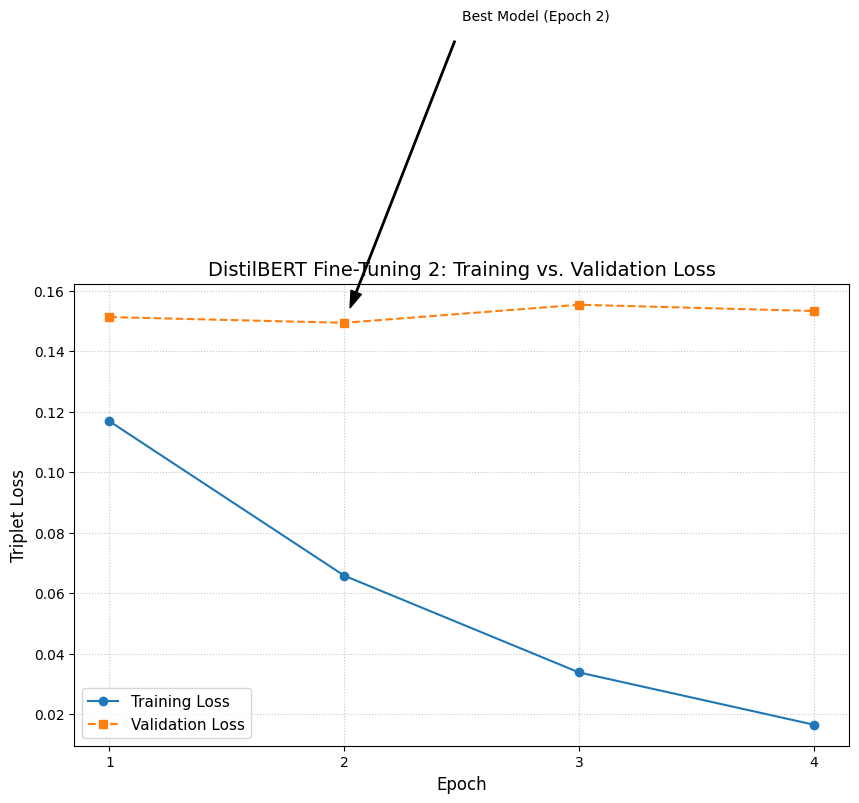

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

epochs_range = range(1, len(train_hist_triplet) + 1)
plt.plot(epochs_range, train_hist_triplet, label='Training Loss', marker='o', linestyle='-', color='#1f77b4')
plt.plot(epochs_range, val_hist_triplet, label='Validation Loss', marker='s', linestyle='--', color='#ff7f0e')

plt.title('DistilBERT Fine-Tuning 2: Training vs. Validation Loss', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Triplet Loss', fontsize=12)

plt.xticks(epochs_range)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=11)

#highlight the best approach
best_epoch = val_hist_triplet.index(min(val_hist_triplet)) + 1
plt.annotate(f'Best Model (Epoch {best_epoch})', 
             xy=(best_epoch, min(val_hist_triplet)), 
             xytext=(best_epoch + 0.5, min(val_hist_triplet) + 0.1),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8))

plt.savefig("plots/fine_tuning_2_triplet_loss_curve.png", dpi=300, bbox_inches='tight')

plt.show()

In [103]:
#restore the checkpoints if exists
#del model
#engine.clear_cache()
#del engine
#model = SentenceTransformer('models/distilbert-finetuned-best-triplet')
#model.to(device)

#print("Model restored from the local folder successfully.")

Model restored from the local folder successfully.


In [73]:
engine = RetrievalEngine(model=model, device=device)

print("Evaluating Fine-Tuned DistilBERT on Test Set...")
for metric in distance_metrics:
    test_results = engine.evaluate_dataset(ds["test"], k=[1, 3, 5], distance_metric=metric)

Evaluating Fine-Tuned DistilBERT on Test Set...


Evaluating Retrieval:   0%|          | 0/2000 [00:00<?, ?it/s]


------------------------------------------------------------------------------------------
FINAL EVALUATION RESULTS
Distance metric: cosine
------------------------------------------------------------------------------------------
Mean Hit@1 : 0.5295
Mean Hit@3 : 0.7465
Mean Hit@5 : 0.8210
Mean MRR  : 0.6613
------------------------------


Evaluating Retrieval:   0%|          | 0/2000 [00:00<?, ?it/s]


------------------------------------------------------------------------------------------
FINAL EVALUATION RESULTS
Distance metric: euclidean
------------------------------------------------------------------------------------------
Mean Hit@1 : 0.5245
Mean Hit@3 : 0.7510
Mean Hit@5 : 0.8270
Mean MRR  : 0.6595
------------------------------


Evaluating Retrieval:   0%|          | 0/2000 [00:00<?, ?it/s]


------------------------------------------------------------------------------------------
FINAL EVALUATION RESULTS
Distance metric: angular
------------------------------------------------------------------------------------------
Mean Hit@1 : 0.5295
Mean Hit@3 : 0.7465
Mean Hit@5 : 0.8210
Mean MRR  : 0.6613
------------------------------


Obviously, choosing random hard negative is not the optimal way so we can improve on it. Nonetheless, model seems to improved itself on the correct chunk.

So now we need to choose hard negatives wisely, i.e the ones looks quite similar the correct one but indeed does not contain the info such as lacking a few word that change the meaning of the sentence.

To do that, within the current state of the fine-tuned model, we compare correct chunk with other corresponding candidates and retrieve 9 most similar chunks which are not the answer. In that way we aim to distinguish the correct one from others.

In [20]:
def mine_hard_negatives(model, dataset_split, num_negatives=9, device='cuda', instruct = False):
    model.eval()
    hard_examples = []
    
    print(f"Mining {num_negatives} hard negatives for {len(dataset_split)} samples...")
    
    with torch.no_grad():
        for i in tqdm(range(len(dataset_split))):
            query = dataset_split[i]["query"]
            pos_idx = dataset_split[i]["answer_pos"]
            chunks = dataset_split[i]["candidate_chunks"]
            
            if not instruct:
                q_text = query
            else:
                instruction = "Represent this sentence for searching relevant passages: "
                q_text = instruction + query

            q_emb = model.encode(q_text, convert_to_tensor=True, device=device, normalize_embeddings=True)
            c_embs = model.encode(chunks, convert_to_tensor=True, device=device, normalize_embeddings=True)
            
            scores = torch.mv(c_embs, q_emb)
            
            # ensuring we don't pick the correct answer as a negative
            scores[pos_idx] = -1.0 
            
            # top-k indices, the chunks the model currently thinks are most similar
            k = min(num_negatives, len(chunks) - 1)
            _, top_indices = torch.topk(scores, k)
            
            positive_chunk = chunks[pos_idx]
            hard_negatives = [chunks[idx] for idx in top_indices.tolist()]
            
            # InputExample: [Query, Positive, Neg1, Neg2, ... Neg9]
            hard_examples.append(InputExample(texts=[query, positive_chunk] + hard_negatives))
            
    return hard_examples

In [104]:
# Mine negatives using latest fine-tuned model
print("Training Set")
train_hard = mine_hard_negatives(model, train_split, num_negatives=9, device=device)

print("Validation Set")
val_hard = mine_hard_negatives(model, val_split, num_negatives=9, device=device)

train_loader_hard = DataLoader(train_hard, shuffle=True, batch_size=16, collate_fn=model.smart_batching_collate)
val_loader_hard = DataLoader(val_hard, shuffle=False, batch_size=16, collate_fn=model.smart_batching_collate)

Training Set
Mining 9 hard negatives for 7000 samples...


  0%|          | 0/7000 [00:00<?, ?it/s]

Validation Set
Mining 9 hard negatives for 1000 samples...


  0%|          | 0/1000 [00:00<?, ?it/s]

We got CUDA out of memory ERROR with L4 gpu. That is understandable since our loss function were normally comparing ground truth with 15 other chunks in a batch but now since each query has 9 negative +1 postive chunk, our positive chunk is compared against 15*10 + 9 = 159 different embeddings so that resulted more vram usage.  We reduce to batch size 8 to see if it resolves.

In [46]:
# deleting old variables if they exist
#if 'model' in locals(): del model
#if 'train_loader_hard' in locals(): del train_loader_hard

#free_gpu_memory()

GPU memory cleared. Released: 0.0 MB | Available now: 770.0 MB


In [68]:
train_loader_hard = DataLoader(train_hard, shuffle=True, batch_size=8, collate_fn=model.smart_batching_collate)
val_loader_hard = DataLoader(val_hard, shuffle=False, batch_size=8, collate_fn=model.smart_batching_collate)

In [72]:
# The loss function remains MultipleNegativesRankingLoss
# It will now compare the query against the positive and 9 mined negatives
hard_loss = losses.MultipleNegativesRankingLoss(model=model)

print("Starting Hard Negative Fine-Tuning...")
train_hist_hard, val_hist_hard = train_retriever(
    model=model,
    train_loss=hard_loss,
    train_dataloader=train_loader_hard,
    val_dataloader=val_loader_hard,
    epochs=15,      
    lr=2e-5,       # Slightly lower learning rate for smaller adjustments
    patience=2,
    device=device
)

Starting Hard Negative Fine-Tuning...


Epochs:   0%|          | 0/15 [00:00<?, ?it/s]

Train Batch (Ep 1):   0%|          | 0/875 [00:00<?, ?it/s]

Val Batch (Ep 1):   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 1 | Train Loss: 1.0970 | Val Loss: 1.5181
Best model updated!


...

Val Batch (Ep 2):   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 2 | Train Loss: 0.6399 | Val Loss: 1.6466
No improvement. Patience: 1/2


Train Batch (Ep 3):   0%|          | 0/875 [00:00<?, ?it/s]

Val Batch (Ep 3):   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 3 | Train Loss: 0.4842 | Val Loss: 1.7569
No improvement. Patience: 2/2

Early stopping triggered at epoch 3!


In the first fine-tuning strategy with only query-positive pairs, the loss function were oscillating around 0.2 to 0.1 but now we can clearly see that the loss started around 1.1 which shows model struggles more and improve itself on finer boundary

In [73]:
model.save("models/distilbert-finetuned-best-hard_mining")

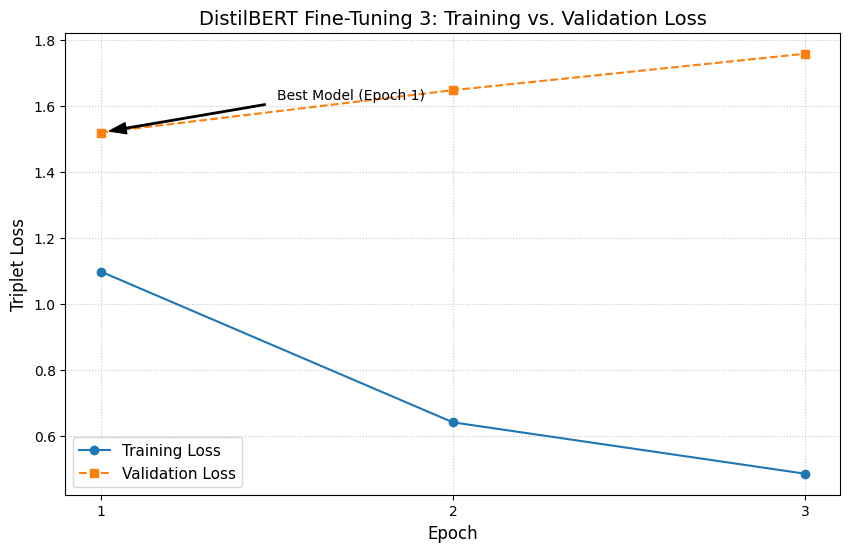

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

epochs_range = range(1, len(train_hist_hard) + 1)
plt.plot(epochs_range, train_hist_hard, label='Training Loss', marker='o', linestyle='-', color='#1f77b4')
plt.plot(epochs_range, val_hist_hard, label='Validation Loss', marker='s', linestyle='--', color='#ff7f0e')

plt.title('DistilBERT Fine-Tuning 3: Training vs. Validation Loss', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)

plt.xticks(epochs_range)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=11)

#highlight the best approach
best_epoch = val_hist_hard.index(min(val_hist_hard)) + 1
plt.annotate(f'Best Model (Epoch {best_epoch})', 
             xy=(best_epoch, min(val_hist_hard)), 
             xytext=(best_epoch + 0.5, min(val_hist_hard) + 0.1),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8))

plt.savefig("plots/fine_tuning_3_hard-mining_loss_curve.png", dpi=300, bbox_inches='tight')

plt.show()

In [74]:
#restore the checkpoints if exists
#del model
#engine.clear_cache()
#del engine
#free_gpu_memory()
#model = SentenceTransformer('models/distilbert-finetuned-best-hard_mining')
#model.to(device)

#print("Model restored from the local folder successfully.")



cache successfully cleared!
GPU memory cleared. Released: 6656.0 MB | Available now: 20021.1 MB
Model restored from the local folder successfully.


In [75]:
engine = RetrievalEngine(model=model, device=device)

print("Evaluating Fine-Tuned DistilBERT on Test Set...")
for metric in distance_metrics:
    test_results = engine.evaluate_dataset(ds["test"], k=[1, 3, 5], distance_metric=metric)

Evaluating Fine-Tuned DistilBERT on Test Set...


Evaluating Retrieval:   0%|          | 0/2000 [00:00<?, ?it/s]


------------------------------------------------------------------------------------------
FINAL EVALUATION RESULTS
Distance metric: cosine
------------------------------------------------------------------------------------------
Mean Hit@1 : 0.6105
Mean Hit@3 : 0.8270
Mean Hit@5 : 0.8970
Mean MRR  : 0.7334
------------------------------


Evaluating Retrieval:   0%|          | 0/2000 [00:00<?, ?it/s]


------------------------------------------------------------------------------------------
FINAL EVALUATION RESULTS
Distance metric: euclidean
------------------------------------------------------------------------------------------
Mean Hit@1 : 0.5935
Mean Hit@3 : 0.8110
Mean Hit@5 : 0.8895
Mean MRR  : 0.7188
------------------------------


Evaluating Retrieval:   0%|          | 0/2000 [00:00<?, ?it/s]


------------------------------------------------------------------------------------------
FINAL EVALUATION RESULTS
Distance metric: angular
------------------------------------------------------------------------------------------
Mean Hit@1 : 0.6105
Mean Hit@3 : 0.8270
Mean Hit@5 : 0.8970
Mean MRR  : 0.7334
------------------------------


this time it tends to overfit even after first epoch. Still improved the accuracy in a good way. Next we will try better models on this task.

In [ ]:
del model
del train_hard
del val_hard
del engine

## all-MiniLM-L6-v2


In [34]:
model_minilm = SentenceTransformer('all-MiniLM-L6-v2').to(device)

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [37]:
# Mining negatives for this model, the top 10 might be different for this one
train_hard = mine_hard_negatives(model_minilm, train_split, num_negatives=9, device=device)

val_hard = mine_hard_negatives(model_minilm, val_split, num_negatives=9, device=device)

Mining 9 hard negatives for 7000 samples...


  0%|          | 0/7000 [00:00<?, ?it/s]

Mining 9 hard negatives for 1000 samples...


  0%|          | 0/1000 [00:00<?, ?it/s]

This model is already way capable of understanding semantic differences of sentences than distilbert given that its training objective is already more aligned with our task, it is expected that with or without fine-tuning it should perform better.

Fine-tuning with hard negatives that we did in the last approach for the distilbert.

In [38]:
minilm_loss = losses.MultipleNegativesRankingLoss(model=model_minilm)

# we can increase batch size since minilm has even less than half parameters than distilbert
train_loader_mini = DataLoader(train_hard, shuffle=True, batch_size=8, collate_fn=model_minilm.smart_batching_collate)
val_loader_mini = DataLoader(val_hard, shuffle=False, batch_size=8, collate_fn=model_minilm.smart_batching_collate)

train_hist_mini, val_hist_mini = train_retriever(
    model=model_minilm,
    train_loss=minilm_loss,
    train_dataloader=train_loader_mini,
    val_dataloader=val_loader_mini,
    epochs=15,              
    lr=3e-6,                # lower learning rate. it has less parameters meaning more prone to miss minima
    device=device
)

Epochs:   0%|          | 0/15 [00:00<?, ?it/s]

Train Batch (Ep 1):   0%|          | 0/875 [00:00<?, ?it/s]

Val Batch (Ep 1):   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 1 | Train Loss: 1.4397 | Val Loss: 1.1774
Best model updated!


Train Batch (Ep 2):   0%|          | 0/875 [00:00<?, ?it/s]

...

Val Batch (Ep 6):   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 6 | Train Loss: 0.8026 | Val Loss: 1.0639
No improvement. Patience: 1/2


Train Batch (Ep 7):   0%|          | 0/875 [00:00<?, ?it/s]

Val Batch (Ep 7):   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 7 | Train Loss: 0.7312 | Val Loss: 1.0617
No improvement. Patience: 2/2
Early stopping triggered at epoch 7!


In [51]:
#restore the checkpoints if exists
#del model
#engine.clear_cache()
#del engine
#free_gpu_memory()
#model_minilm = SentenceTransformer('models/minilm-finetuned-best-hard_mining')
#model_minilm.to(device)

#print("Model restored from the local folder successfully.")

cache successfully cleared!
GPU memory cleared. Released: 6764.0 MB | Available now: 19861.1 MB
Model restored from the local folder successfully.


In [39]:
engine = RetrievalEngine(model=model_minilm, device=device)

print("Evaluating Fine-Tuned all-MiniLM on Test Set...")
for metric in distance_metrics:
    test_results = engine.evaluate_dataset(ds["test"], k=[1, 3, 5], distance_metric=metric)

Evaluating Fine-Tuned all-MiniLM on Test Set...


Evaluating Retrieval:   0%|          | 0/2000 [00:00<?, ?it/s]


------------------------------------------------------------------------------------------
FINAL EVALUATION RESULTS
Distance metric: cosine
------------------------------------------------------------------------------------------
Mean Hit@1 : 0.6240
Mean Hit@3 : 0.8490
Mean Hit@5 : 0.9220
Mean MRR  : 0.7505
------------------------------


Evaluating Retrieval:   0%|          | 0/2000 [00:00<?, ?it/s]


------------------------------------------------------------------------------------------
FINAL EVALUATION RESULTS
Distance metric: euclidean
------------------------------------------------------------------------------------------
Mean Hit@1 : 0.6240
Mean Hit@3 : 0.8490
Mean Hit@5 : 0.9220
Mean MRR  : 0.7505
------------------------------


Evaluating Retrieval:   0%|          | 0/2000 [00:00<?, ?it/s]


------------------------------------------------------------------------------------------
FINAL EVALUATION RESULTS
Distance metric: angular
------------------------------------------------------------------------------------------
Mean Hit@1 : 0.6240
Mean Hit@3 : 0.8490
Mean Hit@5 : 0.9220
Mean MRR  : 0.7505
------------------------------


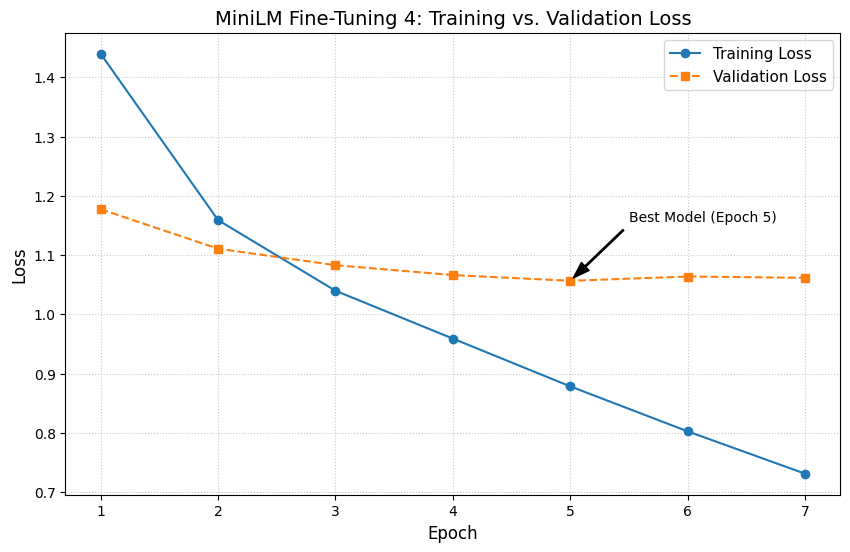

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

epochs_range = range(1, len(train_hist_mini) + 1)
plt.plot(epochs_range, train_hist_mini, label='Training Loss', marker='o', linestyle='-', color='#1f77b4')
plt.plot(epochs_range, val_hist_mini, label='Validation Loss', marker='s', linestyle='--', color='#ff7f0e')

plt.title('MiniLM Fine-Tuning 4: Training vs. Validation Loss', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)

plt.xticks(epochs_range)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=11)

#highlight the best approach
best_epoch = val_hist_mini.index(min(val_hist_mini)) + 1
plt.annotate(f'Best Model (Epoch {best_epoch})', 
             xy=(best_epoch, min(val_hist_mini)), 
             xytext=(best_epoch + 0.5, min(val_hist_mini) + 0.1),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8))

plt.savefig("plots/fine_tuning_4_hard-mining_miniLM2.png", dpi=300, bbox_inches='tight')

plt.show()

In [41]:
model_minilm.save("models/minilm-finetuned-best-hard_mining")
#remove old model from gpu
del model_minilm

even though training went more smooth we are below distilbert performance. This time we will fine-tune SOTA model. As we also seen above, its baseline is quite strong so we expect greater gain from it.

### BGE

In [77]:
model_bge = SentenceTransformer('BAAI/bge-base-en-v1.5').to(device)

engine = RetrievalEngine(model=model_bge, device=device)

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


To experiment and learn how instruction affects performance, we will fine tune the BGE model with and without instruction guidance over query.


1st fine-tuning with instruction guidance

In [26]:
# Mine negatives using latest fine-tuned model
print("Training Set")
train_hard = mine_hard_negatives(model_bge, train_split, num_negatives=9, device=device, instruct=True)

print("Validation Set")
val_hard = mine_hard_negatives(model_bge, val_split, num_negatives=9, device=device, instruct=True)

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Training Set
Mining 9 hard negatives for 7000 samples...


  0%|          | 0/7000 [00:00<?, ?it/s]

Validation Set
Mining 9 hard negatives for 1000 samples...


  0%|          | 0/1000 [00:00<?, ?it/s]

In [29]:
#instructions
bge_loss = losses.MultipleNegativesRankingLoss(model=model_bge)
# this model is quite bigger than others so we are careful with batch size
train_loader_bge = DataLoader(train_hard, shuffle=True, batch_size=4, collate_fn=model_bge.smart_batching_collate)
val_loader_bge = DataLoader(val_hard, shuffle=False, batch_size=4, collate_fn=model_bge.smart_batching_collate)

train_hist_sota, val_hist_sota = train_retriever(
    model=model_bge,
    train_loss=bge_loss,
    train_dataloader=train_loader_bge,
    val_dataloader=val_loader_bge,
    epochs=10,              
    lr=5e-6,                
    device=device
)

Epochs:   0%|          | 0/10 [00:00<?, ?it/s]

Train Batch (Ep 1):   0%|          | 0/1750 [00:00<?, ?it/s]

Val Batch (Ep 1):   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 1 | Train Loss: 1.1181 | Val Loss: 0.9572
Best model updated!


Train Batch (Ep 2):   0%|          | 0/1750 [00:00<?, ?it/s]

...

Val Batch (Ep 3):   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 3 | Train Loss: 0.5533 | Val Loss: 1.0003
No improvement. Patience: 1/2


Train Batch (Ep 4):   0%|          | 0/1750 [00:00<?, ?it/s]

Val Batch (Ep 4):   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 4 | Train Loss: 0.3587 | Val Loss: 1.0378
No improvement. Patience: 2/2
Early stopping triggered at epoch 4!


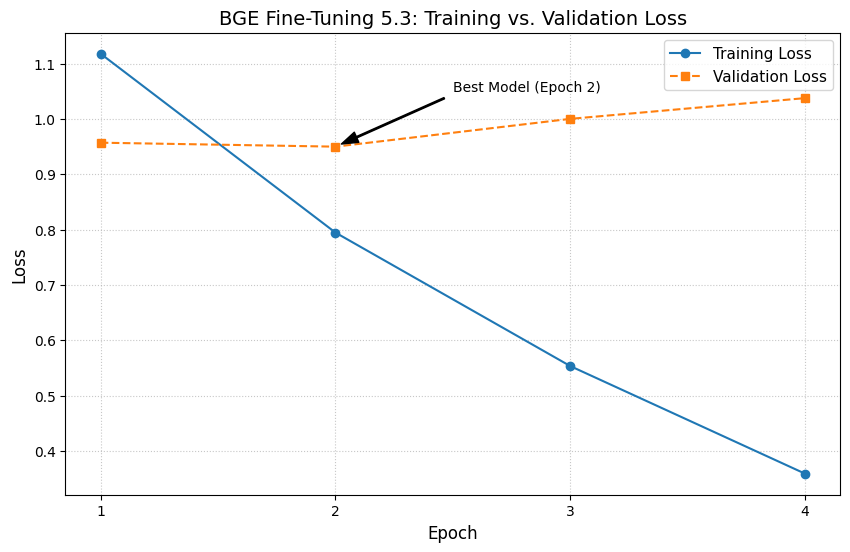

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

epochs_range = range(1, len(train_hist_sota) + 1)
plt.plot(epochs_range, train_hist_sota, label='Training Loss', marker='o', linestyle='-', color='#1f77b4')
plt.plot(epochs_range, val_hist_sota, label='Validation Loss', marker='s', linestyle='--', color='#ff7f0e')

plt.title('BGE Fine-Tuning 5.3: Training vs. Validation Loss', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)

plt.xticks(epochs_range)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=11)

#highlight the best approach
best_epoch = val_hist_sota.index(min(val_hist_sota)) + 1
plt.annotate(f'Best Model (Epoch {best_epoch})', 
             xy=(best_epoch, min(val_hist_sota)), 
             xytext=(best_epoch + 0.5, min(val_hist_sota) + 0.1),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8))

plt.savefig("plots/fine_tuning_5-3_hard-mining_bge2.png", dpi=300, bbox_inches='tight')

plt.show()

In [31]:
model_bge.save("models/bge-finetuned-best-hard_mining-3")

In [32]:
engine = RetrievalEngine(model=model_bge, device=device)

print("Evaluating Fine-Tuned BGE on Test Set...")
for metric in distance_metrics:
    test_results = engine.evaluate_dataset(ds["test"], k=[1, 3, 5], distance_metric=metric)

Evaluating Fine-Tuned BGE on Test Set...


Evaluating Retrieval:   0%|          | 0/2000 [00:00<?, ?it/s]


------------------------------------------------------------------------------------------
FINAL EVALUATION RESULTS
Distance metric: cosine
------------------------------------------------------------------------------------------
Mean Hit@1 : 0.6845
Mean Hit@3 : 0.8860
Mean Hit@5 : 0.9365
Mean MRR  : 0.7941
------------------------------


Evaluating Retrieval:   0%|          | 0/2000 [00:00<?, ?it/s]


------------------------------------------------------------------------------------------
FINAL EVALUATION RESULTS
Distance metric: euclidean
------------------------------------------------------------------------------------------
Mean Hit@1 : 0.6845
Mean Hit@3 : 0.8860
Mean Hit@5 : 0.9365
Mean MRR  : 0.7941
------------------------------


Evaluating Retrieval:   0%|          | 0/2000 [00:00<?, ?it/s]


------------------------------------------------------------------------------------------
FINAL EVALUATION RESULTS
Distance metric: angular
------------------------------------------------------------------------------------------
Mean Hit@1 : 0.6845
Mean Hit@3 : 0.8860
Mean Hit@5 : 0.9365
Mean MRR  : 0.7941
------------------------------


fine-tuning without instruction guidance

In [96]:
bge_loss = losses.MultipleNegativesRankingLoss(model=model_bge)
# this model is quite bigger than others so we are careful with batch size
train_loader_bge = DataLoader(train_hard, shuffle=True, batch_size=4, collate_fn=model_bge.smart_batching_collate)
val_loader_bge = DataLoader(val_hard, shuffle=False, batch_size=4, collate_fn=model_bge.smart_batching_collate)

train_hist_sota, val_hist_sota = train_retriever(
    model=model_bge,
    train_loss=bge_loss,
    train_dataloader=train_loader_bge,
    val_dataloader=val_loader_bge,
    epochs=10,              
    lr=5e-6,                
    device=device
)

Epochs:   0%|          | 0/10 [00:00<?, ?it/s]

Train Batch (Ep 1):   0%|          | 0/1750 [00:00<?, ?it/s]

Val Batch (Ep 1):   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 1 | Train Loss: 1.1170 | Val Loss: 0.9624
Best model updated!


Train Batch (Ep 2):   0%|          | 0/1750 [00:00<?, ?it/s]

Val Batch (Ep 2):   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 2 | Train Loss: 0.7943 | Val Loss: 0.9624
No improvement. Patience: 1/2


Train Batch (Ep 3):   0%|          | 0/1750 [00:00<?, ?it/s]

Val Batch (Ep 3):   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 3 | Train Loss: 0.5515 | Val Loss: 1.0191
No improvement. Patience: 2/2

Early stopping triggered at epoch 3!


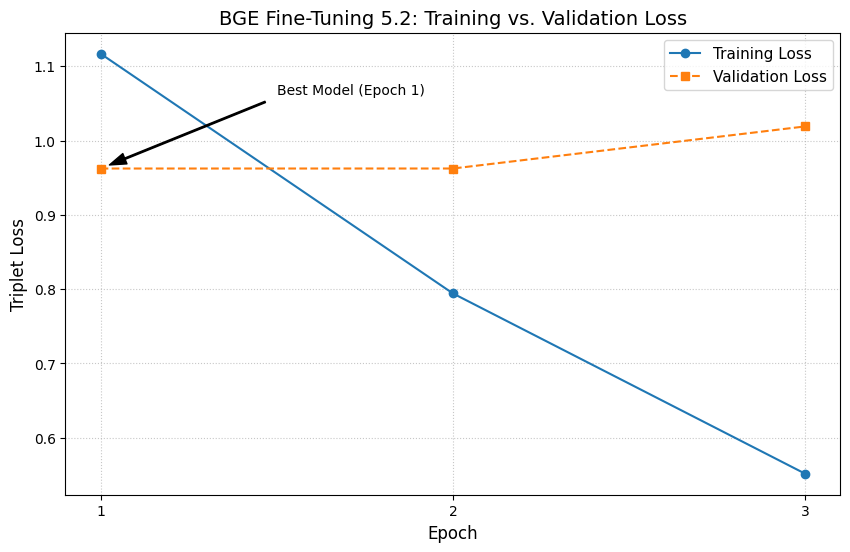

In [97]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

epochs_range = range(1, len(train_hist_sota) + 1)
plt.plot(epochs_range, train_hist_sota, label='Training Loss', marker='o', linestyle='-', color='#1f77b4')
plt.plot(epochs_range, val_hist_sota, label='Validation Loss', marker='s', linestyle='--', color='#ff7f0e')

plt.title('BGE Fine-Tuning 5.2: Training vs. Validation Loss', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)

plt.xticks(epochs_range)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=11)

#highlight the best approach
best_epoch = val_hist_sota.index(min(val_hist_sota)) + 1
plt.annotate(f'Best Model (Epoch {best_epoch})', 
             xy=(best_epoch, min(val_hist_sota)), 
             xytext=(best_epoch + 0.5, min(val_hist_sota) + 0.1),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8))

plt.savefig("plots/fine_tuning_5-2_hard-mining_bge2.png", dpi=300, bbox_inches='tight')

plt.show()

In [98]:
engine = RetrievalEngine(model=model_bge, device=device)

print("Evaluating Fine-Tuned BGE on Test Set...")
for metric in distance_metrics:
    test_results = engine.evaluate_dataset(ds["test"], k=[1, 3, 5], distance_metric=metric)

Evaluating Fine-Tuned BGE on Test Set...


Evaluating Retrieval:   0%|          | 0/2000 [00:00<?, ?it/s]


------------------------------------------------------------------------------------------
FINAL EVALUATION RESULTS
Distance metric: cosine
------------------------------------------------------------------------------------------
Mean Hit@1 : 0.6730
Mean Hit@3 : 0.8925
Mean Hit@5 : 0.9390
Mean MRR  : 0.7897
------------------------------


Evaluating Retrieval:   0%|          | 0/2000 [00:00<?, ?it/s]


------------------------------------------------------------------------------------------
FINAL EVALUATION RESULTS
Distance metric: euclidean
------------------------------------------------------------------------------------------
Mean Hit@1 : 0.6730
Mean Hit@3 : 0.8925
Mean Hit@5 : 0.9390
Mean MRR  : 0.7897
------------------------------


Evaluating Retrieval:   0%|          | 0/2000 [00:00<?, ?it/s]


------------------------------------------------------------------------------------------
FINAL EVALUATION RESULTS
Distance metric: angular
------------------------------------------------------------------------------------------
Mean Hit@1 : 0.6730
Mean Hit@3 : 0.8925
Mean Hit@5 : 0.9390
Mean MRR  : 0.7897
------------------------------


In [99]:
model_bge.save("models/bge-finetuned-best-hard_mining-2")

In [100]:
# del model_bge
# engine.clear_cache()
# del engine

cache successfully cleared!


our best model bge with instruct beated all other baselines and finetuned models. Now we will implement several reranking cross-encoders to see if it also improves our metrics.

## re-ranking

our best performing model "BAAI/bge-base-en-v1.5" has also reranker off-the-shelf model. we will check how it performs with 

utilizing our retrieval engine class, we create a child class using its methods. it also uses caching and safer reranker load to preserve model embeddings to compare different ones.

In [31]:
class RerankerEngine(RetrievalEngine):
    def __init__(self, model, device, reranker_model_name='BAAI/bge-reranker-base'):
        super().__init__(model, device)
        self.load_reranker(reranker_model_name)
        self.model_name = reranker_model_name

    def load_reranker(self, reranker_model_name):
        print(f"Loading Cross-Encoder: {reranker_model_name}...")
        self.reranker_tokenizer = AutoTokenizer.from_pretrained(reranker_model_name)
        self.reranker_model = AutoModelForSequenceClassification.from_pretrained(reranker_model_name).to(self.device)
        self.reranker_model.eval()
        print("Cross-Encoder loaded successfully.")

    def get_reranked_indices(self, query, candidate_chunks, initial_top_k_indices):
        top_k_texts = [candidate_chunks[i] for i in initial_top_k_indices]
        pairs = [[query, chunk_text] for chunk_text in top_k_texts]
        
        with torch.no_grad():
            inputs = self.reranker_tokenizer(
                pairs, 
                padding=True, 
                truncation=True, 
                return_tensors='pt', 
                max_length=512
            ).to(self.device)
            
            scores = self.reranker_model(**inputs, return_dict=True).logits.view(-1,).float()
        
        sorted_indices = torch.argsort(scores, descending=True)
        reranked_indices = [initial_top_k_indices[i] for i in sorted_indices]
        return reranked_indices

    def evaluate_dataset(self,
                         dataset, k=[1, 3, 5],
                        distance_metric="cosine", 
                        eval_metric="all", 
                        use_cache=True, 
                        rerank_top_k=10, 
                        return_predictions = False
                        ):
        
        all_results = []
        
        # caching logic
        if use_cache and id(dataset) != getattr(self, 'cached_dataset_id', None):
            self.embedding_cache.clear()
            self.cached_dataset_id = id(dataset)
        elif not use_cache:
            self.embedding_cache.clear()

        for i, row in enumerate(tqdm(dataset, desc=f"Evaluating Reranker (Top {rerank_top_k})")):
            query_id = row["query_id"]
            correct_index = row.get("answer_pos", -1)
            query = row["query"]
            candidate_chunks = row["candidate_chunks"]

            if use_cache and i in self.embedding_cache:
                query_emb, chunk_embs = self.embedding_cache[i]
            else:
                # BGE Instruct logic
                if "bge" in self.model_name:
                    query_emb = self.get_embeddings([query], instruct=True) 
                else:
                    query_emb = self.get_embeddings([query], instruct=False) 
                chunk_embs = self.get_embeddings(candidate_chunks, instruct=False) 
                if use_cache:
                    self.embedding_cache[i] = (query_emb, chunk_embs)

            # initial ranking from the parent class method
            full_ranking = self.get_ranking(query_emb, chunk_embs, distance_metric)
            current_rerank_k = min(rerank_top_k, len(full_ranking))
            initial_top_k = full_ranking[:current_rerank_k]

            reranked_top_k = self.get_reranked_indices(query, candidate_chunks, initial_top_k)
            final_hybrid_ranking = reranked_top_k + full_ranking[current_rerank_k:]

            all_results.append({
                "query_id": query_id, 
                "correct_index": correct_index,
                "ranking": final_hybrid_ranking
            })

        print("\n" + "---"*20)
        print(f"Results: (Re-ranked Top {rerank_top_k})")
        print(f"Distance metric: {distance_metric}")
        print("---"*20)

        final_results = {}
        
        if eval_metric in ["hitk", "all"]:
            if isinstance(k, list):
                for k_val in k:
                    score = mean_hit_at_k(all_results, k=k_val) 
                    final_results[f"Hit@{k_val}"] = score
                    print(f"Mean Hit@{k_val:<2}: {score:.4f}")
            else:
                score = mean_hit_at_k(all_results, k=k)
                final_results[f"Hit@{k}"] = score
                print(f"Mean Hit@{k:<2}: {score:.4f}")
                
        if eval_metric in ["mrr", "all"]:
            score = mean_reciprocal_rank(all_results) 
            final_results["MRR"] = score
            print(f"Mean MRR  : {score:.4f}")

        print("-" * 60)

        if return_predictions:
            return final_results, all_results

        if eval_metric == "all": return final_results 
        elif eval_metric == "mrr": return final_results["MRR"] 
        elif eval_metric == "hitk": return final_results if isinstance(k, list) else final_results[f"Hit@{k}"]

In [9]:
model_bge = SentenceTransformer('models/bge-finetuned-best-hard_mining-3')
model_bge.to(device)

print("Model restored from the local folder successfully.")

Model restored from the local folder successfully.


now using our best performing model, retrieves top 10 highest similar chunk for a query and re-ranker model ranks them again for the relevance.

In [29]:
reranker_engine = RerankerEngine(
    model=model_bge, 
    device=device, 
    reranker_model_name='BAAI/bge-reranker-base'
)

metrics_test_bge, predictions_test_bge = reranker_engine.evaluate_dataset(
    dataset=ds["test"], 
    k=[1, 3, 5], 
    rerank_top_k=10,
    return_predictions=True 
)

export_predictions_to_jsonl(predictions_test_bge, "bge_bge_rerank", "test")

Evaluating Reranker (Top 10):   0%|          | 0/2000 [00:00<?, ?it/s]


------------------------------------------------------------
Results: (Re-ranked Top 10)
Distance metric: cosine
------------------------------------------------------------
Mean Hit@1 : 0.5650
Mean Hit@3 : 0.7990
Mean Hit@5 : 0.9010
Mean MRR  : 0.7047
------------------------------------------------------------
Successfully saved 2000 predictions to TheLastLanguageBenders-test-bge_bge_rerank.jsonl!


In [34]:
reranker_engine.load_reranker('cross-encoder/ms-marco-MiniLM-L-6-v2')

metrics_test_msmarco, predictions_test_msmarco = reranker_engine.evaluate_dataset(
    dataset=ds["test"], 
    k=[1, 3, 5], 
    rerank_top_k=10,
    return_predictions=True 
)

export_predictions_to_jsonl(predictions_test_msmarco, "bge_minilm_rerank", "test")

Loading Cross-Encoder: cross-encoder/ms-marco-MiniLM-L-6-v2...


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Cross-Encoder loaded successfully.


Evaluating Reranker (Top 10):   0%|          | 0/2000 [00:00<?, ?it/s]


------------------------------------------------------------
Results: (Re-ranked Top 10)
Distance metric: cosine
------------------------------------------------------------
Mean Hit@1 : 0.5940
Mean Hit@3 : 0.8225
Mean Hit@5 : 0.8925
Mean MRR  : 0.7247
------------------------------------------------------------
Successfully saved 2000 predictions to results/TheLastLanguageBenders-test-bge_minilm_rerank.jsonl!


In [35]:
metrics_blind_msmarco, predictions_blind_msmarco = reranker_engine.evaluate_dataset(
    dataset=ds["blind"], 
    k=[1], 
    rerank_top_k=10,
    return_predictions=True 
)
export_predictions_to_jsonl(predictions_blind_msmarco, "bge_minilm_rerank", "blind")

reranker_engine.load_reranker('BAAI/bge-reranker-base')

metrics_blind_bge, predictions_blind_bge = reranker_engine.evaluate_dataset(
    dataset=ds["blind"], 
    k=[1], 
    rerank_top_k=10,
    return_predictions=True 
)
export_predictions_to_jsonl(predictions_blind_bge, "bge_bge_rerank", "blind")

Evaluating Reranker (Top 10):   0%|          | 0/1322 [00:00<?, ?it/s]


------------------------------------------------------------
Results: (Re-ranked Top 10)
Distance metric: cosine
------------------------------------------------------------
Mean Hit@1 : 0.0000
Mean MRR  : 0.0000
------------------------------------------------------------
Successfully saved 1322 predictions to results/TheLastLanguageBenders-blind-bge_minilm_rerank.jsonl!
Loading Cross-Encoder: BAAI/bge-reranker-base...


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Cross-Encoder loaded successfully.


Evaluating Reranker (Top 10):   0%|          | 0/1322 [00:00<?, ?it/s]


------------------------------------------------------------
Results: (Re-ranked Top 10)
Distance metric: cosine
------------------------------------------------------------
Mean Hit@1 : 0.0000
Mean MRR  : 0.0000
------------------------------------------------------------
Successfully saved 1322 predictions to results/TheLastLanguageBenders-blind-bge_bge_rerank.jsonl!


both actually performed worse than fine-tuned bge, our explanation is that re-ranker is not adapted to patterns of the data we used.

## re-chunking experiments

below we will explore some ideas on re-chunking strategies to see if they actually work. Our initial idea is to check how does attention layers of cross-encoder attains in some scenarios and checking if it works how we expected. 

Our initial idea is to use strong cross-encoder model and obtaining its last attention layers to see how well a query attains candidate sentences.


In [9]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk.tokenize import sent_tokenize

model_name = 'BAAI/bge-reranker-base'
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

"""
my initial idea was to give it a hard sentence where we can confuse the model easily. 
I thought rome and capital would align well even if the answer lies in economic and milan. 
To do that we will check the last attention layers' scores to see how the values are for them. 
We will check both average and sum since dense short sentences might cheat on it.
"""

query = "Where is the Italian economic capital located?"
chunk = "Rome is the capital of Italy. It is famous for its history. However, Milan shows a promising way for economic investors. It is located in northern Italy."

inputs = tokenizer(query, chunk, return_tensors='pt', return_offsets_mapping=True)

#seems to a fix for offset mapping
offsets = inputs.pop('offset_mapping')

with torch.no_grad():
    outputs = model(**inputs, output_attentions=True)
    
# attention matrix from the final layer
final_layer_attention = outputs.attentions[-1]

# averaging attention across all 12 heads
avg_attention = final_layer_attention.squeeze(0).mean(dim=0)

[nltk_data] Downloading package punkt to
[nltk_data]     /teamspace/studios/this_studio/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /teamspace/studios/this_studio/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [10]:
seq_ids = inputs.sequence_ids(0)
seq_ids_tensor = torch.tensor([-1 if s is None else s for s in seq_ids])

# 0 is query, 1 is chunk
query_indices = (seq_ids_tensor == 0).nonzero(as_tuple=True)[0]
chunk_indices = (seq_ids_tensor == 1).nonzero(as_tuple=True)[0]

query_to_chunk_attention = avg_attention[query_indices][:, chunk_indices]
token_saliency_scores = query_to_chunk_attention.sum(dim=0)

print(f"Saliency scores: {len(token_saliency_scores)} chunk tokens.")

Saliency scores: 35 chunk tokens.


In [11]:
sentences = sent_tokenize(chunk)
sentence_scores = []
current_token_idx = 0

for sentence in sentences:
    sent_tokens = tokenizer.encode(sentence, add_special_tokens=False)
    num_tokens = len(sent_tokens)
    
    # attention scores for just these tokens
    scores_for_this_sentence = token_saliency_scores[current_token_idx : current_token_idx + num_tokens]
    
    avg_score = scores_for_this_sentence.mean().item()
    sum_score = scores_for_this_sentence.sum().item()
    
    sentence_scores.append((avg_score, sum_score, num_tokens, sentence))
    
    current_token_idx += num_tokens

sentence_scores.sort(key=lambda x: x[0], reverse=True)

print(f"{'Avg Score':<12} | {'Sum Score':<12} | {'Tokens':<8} | {'Sentence'}")
print("-" * 90)

for avg_score, sum_score, num_tokens, sentence in sentence_scores:
    print(f"{avg_score:<12.4f} | {sum_score:<12.4f} | {num_tokens:<8} | {sentence}")

Avg Score    | Sum Score    | Tokens   | Sentence
------------------------------------------------------------------------------------------
0.1485       | 1.0396       | 7        | Rome is the capital of Italy.
0.0801       | 1.0418       | 13       | However, Milan shows a promising way for economic investors.
0.0344       | 0.2410       | 7        | It is famous for its history.
0.0319       | 0.2554       | 8        | It is located in northern Italy.


this is actually not bad, sum of attention scores helped us to retrieve correct sentence even with small difference. We will check it on some of the samples where our model failed to understand.

In [12]:
def extract_sentence_attentions(query, chunk, model, tokenizer):
    inputs = tokenizer(query, chunk, return_tensors='pt', return_offsets_mapping=True)
    inputs.pop('offset_mapping')

    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)
        
    final_layer_attention = outputs.attentions[-1]
    avg_attention = final_layer_attention.squeeze(0).mean(dim=0)
    
    seq_ids = inputs.sequence_ids(0)
    seq_ids_tensor = torch.tensor([-1 if s is None else s for s in seq_ids])
    
    query_indices = (seq_ids_tensor == 0).nonzero(as_tuple=True)[0]
    chunk_indices = (seq_ids_tensor == 1).nonzero(as_tuple=True)[0]
    
    query_to_chunk_attention = avg_attention[query_indices][:, chunk_indices]
    token_saliency_scores = query_to_chunk_attention.sum(dim=0)
    
    print(f"Saliency scores: {len(token_saliency_scores)} chunk tokens.")
    
    sentences = sent_tokenize(chunk)
    sentence_scores = []
    current_token_idx = 0
    
    for sentence in sentences:
        sent_tokens = tokenizer.encode(sentence, add_special_tokens=False)
        num_tokens = len(sent_tokens)
        
        scores_for_this_sentence = token_saliency_scores[current_token_idx : current_token_idx + num_tokens]
        
        avg_score = scores_for_this_sentence.mean().item()
        sum_score = scores_for_this_sentence.sum().item()
        
        sentence_scores.append((avg_score, sum_score, num_tokens, sentence))
        current_token_idx += num_tokens

    sentence_scores.sort(key=lambda x: x[0], reverse=True)

    print(f"{'Avg Score':<12} | {'Sum Score':<12} | {'Tokens':<8} | {'Sentence'}")
    print("-" * 90)

    for avg_score, sum_score, num_tokens, sentence in sentence_scores:
        print(f"{avg_score:<12.4f} | {sum_score:<12.4f} | {num_tokens:<8} | {sentence}")
        
    return sentence_scores

In [13]:
model_bge = SentenceTransformer('models/bge-finetuned-best-hard_mining-3')
model_bge.to(device)

print("Model restored from the local folder successfully.")

Model restored from the local folder successfully.


In [23]:
engine = RetrievalEngine(model_bge, device)

failed_sample = None
predicted_wrong_idx = None

failed_ones = []
for i, row in enumerate(ds["test"]):
    query = row["query"]
    chunks = row["candidate_chunks"]
    correct_idx = row["answer_pos"]
    
    q_emb = engine.get_embeddings([query], instruct=True)
    c_embs = engine.get_embeddings(chunks, instruct=False)
    
    ranking = engine.get_ranking(q_emb, c_embs, distance_metric="cosine")
    
    if ranking[0] != correct_idx:
        print(f"Found a failure at dataset index {i}!")
        failed_sample = row
        predicted_wrong_idx = ranking[0]
        failed_ones.append((failed_sample, predicted_wrong_idx))
        if len(failed_ones) > 2:
            break

for failed_sample, predicted_wrong_idx in failed_ones:
    if failed_sample:
        query = failed_sample["query"]
        correct_chunk = failed_sample["candidate_chunks"][failed_sample["answer_pos"]]
        wrong_chunk = failed_sample["candidate_chunks"][predicted_wrong_idx]

        print(f"Query: '{query}'")
        print(f"Expected Chunk Index: {failed_sample['answer_pos']}")
        print(f"Predicted Chunk Index: {predicted_wrong_idx}")
        
        print("\n" + "---"*30)
        print("correct chunk attention")
        results_true = extract_sentence_attentions(query, correct_chunk, model, tokenizer)
        
        print("\n" + "---"*30)
        print("wrong(predicted) chunk attention")
        results_wrong = extract_sentence_attentions(query, wrong_chunk, model, tokenizer)
        
    else:
        print("no faield test")
    print("\n\n","---"*30)

Found a failure at dataset index 3!
Found a failure at dataset index 6!
Found a failure at dataset index 9!
Query: 'who wrote the song i want you back'
Expected Chunk Index: 2
Predicted Chunk Index: 0

------------------------------------------------------------------------------------------
correct chunk attention
Saliency scores: 324 chunk tokens.
Avg Score    | Sum Score    | Tokens   | Sentence
------------------------------------------------------------------------------------------
0.0214       | 1.4099       | 66       | "I Want You Back" was released on October 7, 1969 and was the first Jackson 5 single to be released by Motown and the first song written and produced by The Corporation, a team comprising Motown chief Berry Gordy, Freddie Perren, Alphonso Mizell, and Deke Richards.
0.0198       | 0.4953       | 25       | The "I Want You Back" bassline is considered by many as the greatest of all time[by whom?]
0.0110       | 1.2369       | 112      | It also is the first of fou

this result is actually surprising for us since all three mistakes, might even be errors except first one which is a bit tricky:
1-
Query: 'who wrote the song i want you back'
correct: "I Want You Back" was released on October 7, 1969 and was the first Jackson 5 single to be released by Motown and the first song written and produced by The Corporation, a team comprising Motown chief Berry Gordy, Freddie Perren, Alphonso Mizell, and Deke Richards.
wrong:"I Want You Back" is a 1969 song by the Jackson 5 which became a number-one hit for the band and the Motown label in early 1970.

their scores are quite similar and wrong one might be deceptive by "by the Jackson 5" part.

2-
Query: 'where is the women's world cup being held'
correct:The 2017 Women's Cricket World Cup was an international women's cricket tournament that took place in England from 24 June to 23 July 2017.
wrong: On 8 February 2016, the International Cricket Council (ICC) announced the five venues for the 2017 Women's World Cup.
Lord's hosted the final, and other matches were played at the home grounds of Derbyshire, Leicestershire, Somerset and Gloucestershire.

the wrong one also explicitly states the places where the tournament held.

3-
Query: 'ethics comes from the greek word 'ethos' which means'
correct:Ethos (/ˈiːθɒs/ or US: /ˈiːθoʊs/) is a Greek word meaning "character" that is used to describe the guiding beliefs or ideals that characterize a community, nation, or ideology.
wrong: Ethos forms the root of ethikos (ἠθικός), meaning "moral, showing moral character".

the phrasing of the wrong answer might be misleading since the "meaning" part can be attained both ethos and ethikos.

In [28]:
correct_ones = []


for i, row in enumerate(ds["test"]):
    query = row["query"]
    chunks = row["candidate_chunks"]   
    correct_idx = row["answer_pos"]  
    
    q_emb = engine.get_embeddings([query], instruct=True)
    c_embs = engine.get_embeddings(chunks, instruct=False)
    
    if not isinstance(q_emb, torch.Tensor):
        q_emb = torch.tensor(q_emb)
    if not isinstance(c_embs, torch.Tensor):
        c_embs = torch.tensor(c_embs)
        
    cosine_scores = F.cosine_similarity(q_emb, c_embs)
    
    ranking = torch.argsort(cosine_scores, descending=True).tolist()

    if ranking[0] == correct_idx:
        print(f"Found a correct hit at index {i}!")
        wrong_idx = ranking[1] 
        
        score_correct = cosine_scores[correct_idx].item()
        score_wrong = cosine_scores[wrong_idx].item()
        margin = score_correct - score_wrong

        correct_ones.append({
            "sample": row,
            "correct_idx": correct_idx,
            "wrong_idx": wrong_idx,
            "score_correct": score_correct,
            "score_wrong": score_wrong,
            "margin": margin
        })
        
        if len(correct_ones) > 2:
            break

for data in correct_ones:
    sample = data["sample"]
    query = sample["query"]
    correct_chunk = sample["candidate_chunks"][data["correct_idx"]]
    wrong_chunk = sample["candidate_chunks"][data["wrong_idx"]]

    print(f"\nQuery: '{query}'")
    print(f"Correct Chunk (Rank 1): {data['correct_idx']} score: {data['score_correct']:.4f}")
    print(f"Wrong Chunk (Rank 2): {data['wrong_idx']} score: {data['score_wrong']:.4f}")
    print(f"Separability Margin: {data['margin']:.4f}")

    print("\n" + "---"*30)
    print("CORRECT CHUNK ATTENTION")
    results_true = extract_sentence_attentions(query, correct_chunk, model, tokenizer)
    
    print("\n" + "---"*30)
    print("WRONG CHUNK ATTENTION")
    results_wrong = extract_sentence_attentions(query, wrong_chunk, model, tokenizer)
    

Found a correct hit at index 0!
Found a correct hit at index 1!
Found a correct hit at index 2!

Query: 'where is the lady with an ermine located'
Correct Chunk (Rank 1): 0 score: 0.4412
Wrong Chunk (Rank 2): 23 score: 0.4281
Separability Margin: 0.0131

------------------------------------------------------------------------------------------
CORRECT CHUNK ATTENTION
Saliency scores: 192 chunk tokens.
Avg Score    | Sum Score    | Tokens   | Sentence
------------------------------------------------------------------------------------------
0.0181       | 1.1403       | 63       | Lady with an Ermine (Italian: Dama con l'ermellino [ˈdaːma kon lermelˈliːno]; Polish: Dama z gronostajem) is a painting by Leonardo da Vinci from around 1489–1490 and one of Poland's national treasures.
0.0148       | 0.6350       | 43       | The painting was purchased in 2016 from the Czartoryski Foundation by the Polish Ministry of Culture and National Heritage for the National Museum in Kraków and has been

Even though, attention scores might be useful where our bi encoder bge model fails, this strongly shows that it can also mislead in the scenarios where bi-encoder finds correct but attention fails to find correct chunks or very close to wrong one.

Instead of recreating correct answer from scratch using all candidate chunks, we will assume correct chunk is ideally correct and try to reduce its token length while making sure the assumed correct answer is still inside the new shortened chunk, i.e. reducing unnecessary sentences.

We plan to keep before or after following sentence to preserve coherence.

In [14]:
def get_attention_scores(query, chunk, model, tokenizer):

    inputs = tokenizer(
        query, 
        chunk, 
        return_tensors='pt', 
        return_offsets_mapping=True, 
        truncation=True, 
        max_length=512
    )
    inputs.pop('offset_mapping')

    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)
        
    final_layer_attention = outputs.attentions[-1]
    avg_attention = final_layer_attention.squeeze(0).mean(dim=0)
    
    seq_ids = inputs.sequence_ids(0)
    seq_ids_tensor = torch.tensor([-1 if s is None else s for s in seq_ids])
    
    query_indices = (seq_ids_tensor == 0).nonzero(as_tuple=True)[0]
    chunk_indices = (seq_ids_tensor == 1).nonzero(as_tuple=True)[0]
    
    query_to_chunk_attention = avg_attention[query_indices][:, chunk_indices]
    token_saliency_scores = query_to_chunk_attention.sum(dim=0)
    
    sentences = sent_tokenize(chunk)
    sentence_data = []
    current_token_idx = 0
    
    for i, sentence in enumerate(sentences):
        sent_tokens = tokenizer.encode(sentence, add_special_tokens=False)
        num_tokens = len(sent_tokens)
        
        if current_token_idx >= len(token_saliency_scores):
            break
            
        available_tokens = min(num_tokens, len(token_saliency_scores) - current_token_idx)
        
        scores_for_this_sentence = token_saliency_scores[current_token_idx : current_token_idx + available_tokens]
        sum_score = scores_for_this_sentence.sum().item()
        
        sentence_data.append({
            "idx": i,
            "sum_score": sum_score,
            "tokens": available_tokens,
            "sentence": sentence
        })
        current_token_idx += num_tokens

    return sentence_data

In [22]:
engine = RetrievalEngine(model_bge, device)
a6_final_submission = []

for i, row in enumerate(tqdm(ds["test"], desc="Re-chunking")):
    query = row["query"]
    chunks = row["candidate_chunks"]
    
    q_emb = engine.get_embeddings([query], instruct=True)
    c_embs = engine.get_embeddings(chunks, instruct=False)
    
    if not isinstance(q_emb, torch.Tensor):
        q_emb = torch.tensor(q_emb)
    if not isinstance(c_embs, torch.Tensor):
        c_embs = torch.tensor(c_embs)
        
    cosine_scores = F.cosine_similarity(q_emb, c_embs)
    
    best_chunk_idx = torch.argmax(cosine_scores).item()
    winning_chunk_text = chunks[best_chunk_idx]
    
    scored_sentences = get_attention_scores(query, winning_chunk_text, model, tokenizer)
    valid_sentences = [s for s in scored_sentences if s['tokens'] >= 5]
    
    if not valid_sentences:
        valid_sentences = scored_sentences 
        
    valid_sentences.sort(key=lambda x: x['sum_score'], reverse=True)
    best_sent_data = valid_sentences[0]
    best_idx = best_sent_data['idx']

    total_sentences = len(scored_sentences)

    if total_sentences == 1:
        dynamic_chunk = scored_sentences[0]['sentence']
        
    elif best_idx == 0:
        # best is first
        dynamic_chunk = scored_sentences[0]['sentence'] + " " + scored_sentences[1]['sentence']
        
    elif best_idx == total_sentences - 1:
        # best is last so before is the 2nd sentence
        dynamic_chunk = scored_sentences[best_idx - 1]['sentence'] + " " + scored_sentences[best_idx]['sentence']
        
    else:
        score_prev = scored_sentences[best_idx - 1]['sum_score']
        score_next = scored_sentences[best_idx + 1]['sum_score']
        
        if score_prev > score_next:
            dynamic_chunk = scored_sentences[best_idx - 1]['sentence'] + " " + scored_sentences[best_idx]['sentence']
        else:
            dynamic_chunk = scored_sentences[best_idx]['sentence'] + " " + scored_sentences[best_idx + 1]['sentence']
            
    
    correct_idx = row["answer_pos"] 

    a6_final_submission.append({
        "query": query,
        "predicted_chunk_id": best_chunk_idx, 
        "actual_chunk_id": correct_idx,       
        "dynamic_chunk_text": dynamic_chunk   
    })

Re-chunking:   0%|          | 0/2000 [00:00<?, ?it/s]

In [21]:
import random
for i in range(min(5, len(a6_final_submission))):
    idx = random.randint(0,2000)
    sample = a6_final_submission[idx]
    query = sample["query"]
    predicted_idx = sample["predicted_chunk_id"]
    dynamic_text = sample["dynamic_chunk_text"]
    
    original_text = ds["test"][idx]["candidate_chunks"][predicted_idx]
    
    orig_words = len(original_text.split())
    dyn_words = len(dynamic_text.split())
    
    print(f"Sample {i+1}:")
    print(f"Query: '{query}'")
    print("-" * 30)
    print(f"original one: ({orig_words}:")
    print(original_text)
    print("\n" + "-" * 30)
    print(f"dynamic one: ({dyn_words}:")
    print(dynamic_text)

Sample 1:
Query: 'what is a woman's work lyrics about'
------------------------------
original one: (120:
The lyric of "This Woman's Work" is about being forced to confront an unexpected and frightening crisis during the normal event of childbirth. Written for the movie She's Having a Baby, director John Hughes used the song during the film's dramatic climax, when Jake (Kevin Bacon) learns that the lives of his wife, Kristy (Elizabeth McGovern), and their unborn child are in danger. As the song plays, we see a montage sequence of flashbacks showing the couple in happier times, intercut with shots of him waiting for news of Kristy and their baby's condition. Bush wrote the song specifically for the sequence, writing from a man's (Jake's) viewpoint and matching the words to the visuals which had already been filmed.

------------------------------
dynamic one: (63:
The lyric of "This Woman's Work" is about being forced to confront an unexpected and frightening crisis during the normal ev

this seems promising the random samples we checked shows promising result by keeping the correct answer while reducing token length.

Below you will see the evaluation logic where we used another cross encoder to check how well we performed. 
ms-marco-MiniLM-L-6-v2 model was returning raw logits so we applied softmax to get probabilities and the most cruical part is our logic where we define what correct answer is. We defined either probability is more than %50 or around %10-margin of original answer if both below %50.

In [24]:
judge_name = 'cross-encoder/ms-marco-MiniLM-L-6-v2'
judge_tokenizer = AutoTokenizer.from_pretrained(judge_name)
judge_model = AutoModelForSequenceClassification.from_pretrained(judge_name)
judge_model.eval()

original_token_counts = []
dynamic_token_counts = []
retention_successes = 0
valid_original_answers = 0 
total_evaluated = len(a6_final_submission)

for i, submission in enumerate(tqdm(a6_final_submission, desc="Answer Retention")):
    query = submission["query"]
    dynamic_chunk = submission["dynamic_chunk_text"]
    
    original_chunk_idx = submission["predicted_chunk_id"]
    original_chunk = ds["test"][i]["candidate_chunks"][original_chunk_idx]
    
    #compression ratio
    orig_tokens = len(judge_tokenizer.encode(original_chunk, add_special_tokens=False))
    dyn_tokens = len(judge_tokenizer.encode(dynamic_chunk, add_special_tokens=False))
    
    original_token_counts.append(orig_tokens)
    dynamic_token_counts.append(dyn_tokens)
    
    # answer retention
    inputs_orig = judge_tokenizer(query, original_chunk, return_tensors="pt", truncation=True)
    inputs_dyn = judge_tokenizer(query, dynamic_chunk, return_tensors="pt", truncation=True)
    
    with torch.no_grad():
        logit_orig = judge_model(**inputs_orig).logits.item()
        logit_dyn = judge_model(**inputs_dyn).logits.item()
    
    prob_orig = torch.sigmoid(torch.tensor(logit_orig)).item()
    prob_dyn = torch.sigmoid(torch.tensor(logit_dyn)).item()

    # chunks where the original actually contained the answer
    if prob_orig >= 0.5:
        valid_original_answers += 1 
        
        # success dynamic chunk is still highly probable (>0.5) 
        # or the probability drop was very small
        if prob_dyn >= 0.5 or (prob_orig - prob_dyn < 0.10):
            retention_successes += 1

print("\n" + "---"*30)

avg_orig_tokens = np.mean(original_token_counts)
avg_dyn_tokens = np.mean(dynamic_token_counts)
compression_percentage = (1 - (avg_dyn_tokens / avg_orig_tokens)) * 100

print(f"Average Original Chunk Size: {avg_orig_tokens:.1f} tokens")
print(f"Average Dynamic Chunk Size: {avg_dyn_tokens:.1f} tokens")
print(f"Total Text Compression: {compression_percentage:.1f}% Reduction in context size")
print("---" * 30)

if valid_original_answers > 0:
    retention_rate = (retention_successes / valid_original_answers) * 100
    print(f"Valid Baseline Answers: {valid_original_answers}/{total_evaluated}")
    print(f"Answer Retention Rate: {retention_rate:.1f}%")
else:
    print("Answer Retention Rate:0")

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Answer Retention:   0%|          | 0/2000 [00:00<?, ?it/s]


------------------------------------------------------------------------------------------
Average Original Chunk Size: 116.1 tokens
Average Dynamic Chunk Size: 64.9 tokens
Total Text Compression: 44.1% Reduction in context size
------------------------------------------------------------------------------------------
Valid Baseline Answers: 1805/2000
Answer Retention Rate: 91.5%


This actually shows great impact while retaining answer in %90 of the samples we reduced token size by %50.

In [32]:
output_filename = "results/TheLastLanguageBender-test-rechunked.jsonl"

with open(output_filename, 'w', encoding='utf-8') as f:
    for row in a6_final_submission:
        f.write(json.dumps(row, ensure_ascii=False) + "\n")

print(f"Successfully saved {len(a6_final_submission)} dynamically chunked samples to {output_filename}!")

Successfully saved 2000 dynamically chunked samples to results/TheLastLanguageBender-rechunked.jsonl!


In [15]:
#same on blind

engine = RetrievalEngine(model_bge, device)
a6_final_submission_blind = []

for i, row in enumerate(tqdm(ds["blind"], desc="Re-chunking")):
    query = row["query"]
    chunks = row["candidate_chunks"]
    
    q_emb = engine.get_embeddings([query], instruct=True)
    c_embs = engine.get_embeddings(chunks, instruct=False)
    
    if not isinstance(q_emb, torch.Tensor):
        q_emb = torch.tensor(q_emb)
    if not isinstance(c_embs, torch.Tensor):
        c_embs = torch.tensor(c_embs)
        
    cosine_scores = F.cosine_similarity(q_emb, c_embs)
    
    best_chunk_idx = torch.argmax(cosine_scores).item()
    winning_chunk_text = chunks[best_chunk_idx]
    
    scored_sentences = get_attention_scores(query, winning_chunk_text, model, tokenizer)
    valid_sentences = [s for s in scored_sentences if s['tokens'] >= 5]
    
    if not valid_sentences:
        valid_sentences = scored_sentences 
        
    valid_sentences.sort(key=lambda x: x['sum_score'], reverse=True)
    best_sent_data = valid_sentences[0]
    best_idx = best_sent_data['idx']

    total_sentences = len(scored_sentences)

    if total_sentences == 1:
        dynamic_chunk = scored_sentences[0]['sentence']
        
    elif best_idx == 0:
        # best is first
        dynamic_chunk = scored_sentences[0]['sentence'] + " " + scored_sentences[1]['sentence']
        
    elif best_idx == total_sentences - 1:
        # best is last so before is the 2nd sentence
        dynamic_chunk = scored_sentences[best_idx - 1]['sentence'] + " " + scored_sentences[best_idx]['sentence']
        
    else:
        score_prev = scored_sentences[best_idx - 1]['sum_score']
        score_next = scored_sentences[best_idx + 1]['sum_score']
        
        if score_prev > score_next:
            dynamic_chunk = scored_sentences[best_idx - 1]['sentence'] + " " + scored_sentences[best_idx]['sentence']
        else:
            dynamic_chunk = scored_sentences[best_idx]['sentence'] + " " + scored_sentences[best_idx + 1]['sentence']
            
    

    a6_final_submission_blind.append({
        "query": query,
        "predicted_chunk_id": best_chunk_idx,       
        "dynamic_chunk_text": dynamic_chunk   
    })

Re-chunking:   0%|          | 0/1322 [00:00<?, ?it/s]

In [16]:
output_filename = "results/TheLastLanguageBender-blind-rechunked.jsonl"

with open(output_filename, 'w', encoding='utf-8') as f:
    for row in a6_final_submission_blind:
        f.write(json.dumps(row, ensure_ascii=False) + "\n")

print(f"Successfully saved {len(a6_final_submission_blind)} dynamically chunked samples to {output_filename}!")

Successfully saved 1322 dynamically chunked samples to results/TheLastLanguageBender-blind-rechunked.jsonl!


## Saving json outputs for each model

In [40]:
model_name = "distilbert-base-uncased"

word_embedding_model = models.Transformer(model_name)

pooling_model = models.Pooling(
    word_embedding_model.get_word_embedding_dimension(),
    pooling_mode_mean_tokens=True
)

model = SentenceTransformer(modules=[word_embedding_model, pooling_model])
model = model.to(device)
engine = RetrievalEngine(model=model, device=device)

_, predictions_test = engine.evaluate_dataset(
    dataset=ds["test"], 
    return_predictions=True
)
export_predictions_to_jsonl(predictions_test, f"{model_name}", "test")
_, predictions_test = engine.evaluate_dataset(
    dataset=ds["blind"], 
    return_predictions=True
)
export_predictions_to_jsonl(predictions_test, f"{model_name}", "blind")

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Evaluating Retrieval:   0%|          | 0/2000 [00:00<?, ?it/s]


------------------------------------------------------------------------------------------
FINAL EVALUATION RESULTS
Distance metric: cosine
------------------------------------------------------------------------------------------
Mean Hit@1 : 0.1765
Mean Hit@3 : 0.4435
Mean Hit@5 : 0.6045
Mean MRR  : 0.3657
------------------------------
Successfully saved 2000 predictions to results/TheLastLanguageBenders-test-distilbert-base-uncased.jsonl!


Evaluating Retrieval:   0%|          | 0/1322 [00:00<?, ?it/s]


------------------------------------------------------------------------------------------
FINAL EVALUATION RESULTS
Distance metric: cosine
------------------------------------------------------------------------------------------
Mean Hit@1 : 0.0000
Mean Hit@3 : 0.0000
Mean Hit@5 : 0.0000
Mean MRR  : 0.0000
------------------------------
Successfully saved 1322 predictions to results/TheLastLanguageBenders-blind-distilbert-base-uncased.jsonl!


In [41]:
model_name = "all-MiniLM-L6-v2"

model = SentenceTransformer(model_name).to(device)
engine = RetrievalEngine(model=model, device=device)

_, predictions_test = engine.evaluate_dataset(
    dataset=ds["test"], 
    return_predictions=True
)
export_predictions_to_jsonl(predictions_test, f"{model_name}", "test")
_, predictions_test = engine.evaluate_dataset(
    dataset=ds["blind"], 
    return_predictions=True
)
export_predictions_to_jsonl(predictions_test, f"{model_name}", "blind")

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Evaluating Retrieval:   0%|          | 0/2000 [00:00<?, ?it/s]


------------------------------------------------------------------------------------------
FINAL EVALUATION RESULTS
Distance metric: cosine
------------------------------------------------------------------------------------------
Mean Hit@1 : 0.4480
Mean Hit@3 : 0.7165
Mean Hit@5 : 0.8080
Mean MRR  : 0.6093
------------------------------
Successfully saved 2000 predictions to results/TheLastLanguageBenders-test-all-MiniLM-L6-v2.jsonl!


Evaluating Retrieval:   0%|          | 0/1322 [00:00<?, ?it/s]


------------------------------------------------------------------------------------------
FINAL EVALUATION RESULTS
Distance metric: cosine
------------------------------------------------------------------------------------------
Mean Hit@1 : 0.0000
Mean Hit@3 : 0.0000
Mean Hit@5 : 0.0000
Mean MRR  : 0.0000
------------------------------
Successfully saved 1322 predictions to results/TheLastLanguageBenders-blind-all-MiniLM-L6-v2.jsonl!


In [43]:
model_name = "BAAI/bge-base-en-v1.5"

model = SentenceTransformer(model_name).to(device)
engine = RetrievalEngine(model=model, device=device)

_, predictions_test = engine.evaluate_dataset(
    dataset=ds["test"],
    instruct=True, 
    return_predictions=True
)
export_predictions_to_jsonl(predictions_test, "bge-base-en-v1.5", "test")
_, predictions_test = engine.evaluate_dataset(
    dataset=ds["blind"], 
    instruct=True,
    return_predictions=True
)
export_predictions_to_jsonl(predictions_test, "bge-base-en-v1.5", "blind")

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Evaluating Retrieval:   0%|          | 0/2000 [00:00<?, ?it/s]


------------------------------------------------------------------------------------------
FINAL EVALUATION RESULTS
Distance metric: cosine
------------------------------------------------------------------------------------------
Mean Hit@1 : 0.5460
Mean Hit@3 : 0.8040
Mean Hit@5 : 0.8815
Mean MRR  : 0.6922
------------------------------
Successfully saved 2000 predictions to results/TheLastLanguageBenders-test-bge-base-en-v1.5.jsonl!


Evaluating Retrieval:   0%|          | 0/1322 [00:00<?, ?it/s]


------------------------------------------------------------------------------------------
FINAL EVALUATION RESULTS
Distance metric: cosine
------------------------------------------------------------------------------------------
Mean Hit@1 : 0.0000
Mean Hit@3 : 0.0000
Mean Hit@5 : 0.0000
Mean MRR  : 0.0000
------------------------------
Successfully saved 1322 predictions to results/TheLastLanguageBenders-blind-bge-base-en-v1.5.jsonl!


In [44]:
model_name = "models/distilbert-finetuned-best-hard_mining"

model = SentenceTransformer(model_name).to(device)
engine = RetrievalEngine(model=model, device=device)

_, predictions_test = engine.evaluate_dataset(
    dataset=ds["test"], 
    return_predictions=True
)
export_predictions_to_jsonl(predictions_test, "distilbert-hardNegatives", "test")
_, predictions_test = engine.evaluate_dataset(
    dataset=ds["blind"], 
    return_predictions=True
)
export_predictions_to_jsonl(predictions_test, "distilbert-hardNegatives", "blind")

Evaluating Retrieval:   0%|          | 0/2000 [00:00<?, ?it/s]


------------------------------------------------------------------------------------------
FINAL EVALUATION RESULTS
Distance metric: cosine
------------------------------------------------------------------------------------------
Mean Hit@1 : 0.6105
Mean Hit@3 : 0.8270
Mean Hit@5 : 0.8970
Mean MRR  : 0.7334
------------------------------
Successfully saved 2000 predictions to results/TheLastLanguageBenders-test-distilbert-hardNegatives.jsonl!


Evaluating Retrieval:   0%|          | 0/1322 [00:00<?, ?it/s]


------------------------------------------------------------------------------------------
FINAL EVALUATION RESULTS
Distance metric: cosine
------------------------------------------------------------------------------------------
Mean Hit@1 : 0.0000
Mean Hit@3 : 0.0000
Mean Hit@5 : 0.0000
Mean MRR  : 0.0000
------------------------------
Successfully saved 1322 predictions to results/TheLastLanguageBenders-blind-distilbert-hardNegatives.jsonl!


In [46]:
model_name = "models/minilm-finetuned-best-hard_mining"

model = SentenceTransformer(model_name).to(device)
engine = RetrievalEngine(model=model, device=device)

_, predictions_test = engine.evaluate_dataset(
    dataset=ds["test"], 
    return_predictions=True
)
export_predictions_to_jsonl(predictions_test, "minilm-hardNegatives", "test")
_, predictions_test = engine.evaluate_dataset(
    dataset=ds["blind"], 
    return_predictions=True
)
export_predictions_to_jsonl(predictions_test, "minilm-hardNegatives", "blind")

Evaluating Retrieval:   0%|          | 0/2000 [00:00<?, ?it/s]


------------------------------------------------------------------------------------------
FINAL EVALUATION RESULTS
Distance metric: cosine
------------------------------------------------------------------------------------------
Mean Hit@1 : 0.6240
Mean Hit@3 : 0.8490
Mean Hit@5 : 0.9220
Mean MRR  : 0.7505
------------------------------
Successfully saved 2000 predictions to results/TheLastLanguageBenders-test-minilm-hardNegatives.jsonl!


Evaluating Retrieval:   0%|          | 0/1322 [00:00<?, ?it/s]


------------------------------------------------------------------------------------------
FINAL EVALUATION RESULTS
Distance metric: cosine
------------------------------------------------------------------------------------------
Mean Hit@1 : 0.0000
Mean Hit@3 : 0.0000
Mean Hit@5 : 0.0000
Mean MRR  : 0.0000
------------------------------
Successfully saved 1322 predictions to results/TheLastLanguageBenders-blind-minilm-hardNegatives.jsonl!


In [47]:
model_name = "models/bge-finetuned-best-hard_mining-3"

model = SentenceTransformer(model_name).to(device)
engine = RetrievalEngine(model=model, device=device)

_, predictions_test = engine.evaluate_dataset(
    dataset=ds["test"], 
    instruct=True,
    return_predictions=True
)
export_predictions_to_jsonl(predictions_test, "bge-hardNegatives", "test")
_, predictions_test = engine.evaluate_dataset(
    dataset=ds["blind"], 
    instruct=True,
    return_predictions=True
)
export_predictions_to_jsonl(predictions_test, "bge-hardNegatives", "blind")

Evaluating Retrieval:   0%|          | 0/2000 [00:00<?, ?it/s]


------------------------------------------------------------------------------------------
FINAL EVALUATION RESULTS
Distance metric: cosine
------------------------------------------------------------------------------------------
Mean Hit@1 : 0.6190
Mean Hit@3 : 0.8555
Mean Hit@5 : 0.9190
Mean MRR  : 0.7489
------------------------------
Successfully saved 2000 predictions to results/TheLastLanguageBenders-test-bge-hardNegatives.jsonl!


Evaluating Retrieval:   0%|          | 0/1322 [00:00<?, ?it/s]


------------------------------------------------------------------------------------------
FINAL EVALUATION RESULTS
Distance metric: cosine
------------------------------------------------------------------------------------------
Mean Hit@1 : 0.0000
Mean Hit@3 : 0.0000
Mean Hit@5 : 0.0000
Mean MRR  : 0.0000
------------------------------
Successfully saved 1322 predictions to results/TheLastLanguageBenders-blind-bge-hardNegatives.jsonl!
